# 05 Conformal Prediction and Boundary-Adaptive Scoring

## 1. Purpose and Experimental Contract

This notebook evaluates whether architecture-specific boundary uncertainty can improve conformal prediction sets for Transformer-based Named Entity Recognition. It compares four progressively structured candidate-level nonconformity scores for the frozen BERT BIO and SpanNER models.

| Method | Candidate-level nonconformity score | Role |
|---|---|---|
| **M1** | `1 − c` | Confidence-only baseline |
| **M2** | `(1 − c) + ½λ(Rₛ + Rₑ)` | Shared fixed boundary-rank adjustment |
| **M3** | `(1 − c) + ½(λₛRₛ + λₑRₑ)` | Separate fixed start/end boundary-rank adjustment |
| **M4** | `(1 − c) + ½[λₛ(1 − uₛ)Rₛ + λₑ(1 − uₑ)Rₑ]` | Boundary-uncertainty-adaptive adjustment |

Here, `c` is the temperature-scaled architecture-native confidence of a typed span candidate; `Rₛ` and `Rₑ` are normalized start- and end-boundary ranks; and `uₛ` and `uₑ` are the deterministic architecture-specific local boundary-uncertainty signals established in the earlier model notebooks.

The conformal experiment follows the fixed Notebook-00 population registry:

- **1,625 validation sentences** are used exclusively for M2–M4 λ development through deterministic five-fold grouped cross-fitting.
- **650 conformal-calibration sentences** are reserved for estimating the final conformal quantiles only after the score definitions and λ configurations have been frozen.
- The separate **975-sentence probability-calibration population** has already been used by Notebook 04 and is not reused for conformal tuning.
- The **official CoNLL-2003 test set remains locked** and is not loaded, inspected or evaluated in this notebook.

Temperature scaling from Notebook 04 is propagated into the primary conformal experiment. Binary boundary-correctness calibration remains a secondary diagnostic and is **not** incorporated into M1–M4. MC Dropout is likewise excluded from the conformal scores.

For M4, the original deterministic uncertainty definitions are retained. BERT uses local BIO boundary ambiguity, while SpanNER uses same-type competing spans. For SpanNER conformal candidate construction, absence of an eligible competitor gives `u = 0`, indicating that no observed local competition is available to relax the corresponding boundary-rank penalty. This is distinct from the missing-score treatment used for binary-calibration diagnostics.

The primary evaluation criterion is **sentence-level representable-gold coverage**: a sentence is covered only when every representable gold typed entity is included in its conformal prediction set. Efficiency is measured by the **mean number of typed span candidates included per sentence**.

The principal target coverage is 90%, with 95% and 99% retained as secondary operating points. M4 is evaluated as a predefined adaptive extension of M3; it is not assumed to outperform the fixed alternatives.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd

# Fixed experimental design inherited from Notebook 00.
SEED = 42

ORIGINAL_VALIDATION_SENTENCES = 3250
PROBABILITY_CALIBRATION_SENTENCES = 975
CONFORMAL_CALIBRATION_SENTENCES = 650
VALIDATION_SENTENCES = 1625

N_TUNING_FOLDS = 5
TUNING_FOLD_SIZE = 325

TARGET_COVERAGES = (0.90, 0.95, 0.99)
ENTITY_TYPES = ("PER", "ORG", "LOC", "MISC")

# Binary correctness calibrators remain secondary diagnostics and are
# deliberately excluded from the primary M1-M4 conformal experiment.
BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4 = False

experiment_contract = {
    "seed": SEED,
    "original_validation_sentences": ORIGINAL_VALIDATION_SENTENCES,
    "probability_calibration_sentences": PROBABILITY_CALIBRATION_SENTENCES,
    "conformal_calibration_sentences": CONFORMAL_CALIBRATION_SENTENCES,
    "independent_validation_sentences": VALIDATION_SENTENCES,
    "lambda_selection_folds": N_TUNING_FOLDS,
    "sentences_per_lambda_fold": TUNING_FOLD_SIZE,
    "target_coverages": list(TARGET_COVERAGES),
    "temperature_scaling_used": True,
    "binary_correctness_calibration_role": "secondary_diagnostic",
    "binary_calibrators_used_in_primary_M1_M4": (
        BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4
    ),
    "mc_dropout_used_in_primary_M1_M4": False,
    "official_test_accessed": False,
}

print("Notebook 05 experimental contract")
display(
    pd.DataFrame(
        {
            "Population": [
                "Probability calibration",
                "Conformal calibration",
                "Independent validation",
            ],
            "Sentences": [
                PROBABILITY_CALIBRATION_SENTENCES,
                CONFORMAL_CALIBRATION_SENTENCES,
                VALIDATION_SENTENCES,
            ],
            "Role in Notebook 05": [
                "Not reused for conformal fitting",
                "Final conformal quantile estimation only",
                "Lambda selection and validation evaluation",
            ],
        }
    )
)

print(f"\nLambda-development folds: {N_TUNING_FOLDS} × {TUNING_FOLD_SIZE}")
print("Target coverages:", TARGET_COVERAGES)
print(
    "Binary correctness calibrators used in M1-M4:",
    BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4,
)
print("Official CoNLL test accessed:", False)

Notebook 05 experimental contract


,Population,Sentences,Role in Notebook 05
0,Probability calibration,975,Not reused for conformal fitting
1,Conformal calibration,650,Final conformal quantile estimation only
2,Independent validation,1625,Lambda selection and validation evaluation



Lambda-development folds: 5 × 325
Target coverages: (0.9, 0.95, 0.99)
Binary correctness calibrators used in M1-M4: False
Official CoNLL test accessed: False


## 2. Frozen Upstream Artefacts

The conformal experiment reuses the fixed data registry and deterministic model outputs established in the preceding notebooks. No model is retrained and no development population is resampled here.

The required upstream sources are:

- **Notebook 00:** fixed validation, probability-calibration and conformal-calibration assignments;
- **Notebook 01:** deterministic BERT token-level outputs for the validation and conformal-calibration populations;
- **Notebook 02:** deterministic SpanNER candidate-level outputs for the same populations;
- **Notebook 04:** the frozen temperature-scaling specification.

Notebook 03 is attached for project continuity but is not required to construct the primary M1–M4 conformal scores. Its uncertainty-comparison results are descriptive evidence rather than conformal inputs.

Only multiclass temperature scaling from Notebook 04 propagates into this experiment. The binary boundary-correctness calibrators remain secondary diagnostics and are not loaded into the M1–M4 scoring pipeline.

In [2]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")


def find_unique_file(filename):
    """Return the unique attached Kaggle artefact with the requested filename."""
    matches = list(KAGGLE_INPUT_ROOT.rglob(filename))

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one '{filename}' artefact, found {len(matches)}."
        )

    return matches[0]


# Notebook 00 is identified by the permanent split registry.
split_indices_path = find_unique_file("split_indices.json")
NOTEBOOK00_ROOT = split_indices_path.parent

with split_indices_path.open("r", encoding="utf-8") as file:
    split_information = json.load(file)

# Notebook 01 and 02 are identified by their reusable deterministic outputs.
bert_validation_path = find_unique_file("validation_token_predictions.csv")
bert_conformal_path = find_unique_file("conformal_calibration_token_predictions.csv")

spanner_validation_path = find_unique_file("validation_candidate_predictions.csv")
spanner_conformal_path = find_unique_file(
    "conformal_calibration_candidate_predictions.csv"
)

NOTEBOOK01_ROOT = bert_validation_path.parents[1]
NOTEBOOK02_ROOT = spanner_validation_path.parents[1]

# Display only calibration-related JSON artefacts from Notebook 04 so that
# the final frozen temperature specification can be selected explicitly.
calibration_json_paths = sorted(
    path
    for path in KAGGLE_INPUT_ROOT.rglob("*.json")
    if "04" in str(path.parent).lower()
    or "calib" in str(path).lower()
    or "temperature" in str(path).lower()
)

dependency_summary_df = pd.DataFrame(
    [
        {
            "Source": "Notebook 00",
            "Artefact": split_indices_path.name,
            "Resolved": split_indices_path.is_file(),
        },
        {
            "Source": "Notebook 01",
            "Artefact": bert_validation_path.name,
            "Resolved": bert_validation_path.is_file(),
        },
        {
            "Source": "Notebook 01",
            "Artefact": bert_conformal_path.name,
            "Resolved": bert_conformal_path.is_file(),
        },
        {
            "Source": "Notebook 02",
            "Artefact": spanner_validation_path.name,
            "Resolved": spanner_validation_path.is_file(),
        },
        {
            "Source": "Notebook 02",
            "Artefact": spanner_conformal_path.name,
            "Resolved": spanner_conformal_path.is_file(),
        },
    ]
)

print("Table: Resolved Core Upstream Artefacts")
display(dependency_summary_df)

print("\nNotebook 04 calibration JSON artefacts:")
for path in calibration_json_paths:
    print(" -", path)

Table: Resolved Core Upstream Artefacts


,Source,Artefact,Resolved
0,Notebook 00,split_indices.json,True
1,Notebook 01,validation_token_predictions.csv,True
2,Notebook 01,conformal_calibration_token_predictions.csv,True
3,Notebook 02,validation_candidate_predictions.csv,True
4,Notebook 02,conformal_calibration_candidate_predictions.csv,True



Notebook 04 calibration JSON artefacts:
 - /kaggle/input/datasets/umrahzargar/02-spanner-new/02_spanner_baseline_and_uncertainty/metrics/conformal_calibration_reference_metrics.json
 - /kaggle/input/datasets/umrahzargar/02-spanner-new/02_spanner_baseline_and_uncertainty/metrics/probability_calibration_reference_metrics.json
 - /kaggle/input/datasets/umrahzargar/04-probability-new/04_probability_and_boundary_calibration/completion_record.json
 - /kaggle/input/datasets/umrahzargar/04-probability-new/04_probability_and_boundary_calibration/configuration/calibration_protocol.json
 - /kaggle/input/datasets/umrahzargar/04-probability-new/04_probability_and_boundary_calibration/configuration/downstream_calibration_specification.json
 - /kaggle/input/datasets/umrahzargar/04-probability-new/04_probability_and_boundary_calibration/configuration/environment_information.json
 - /kaggle/input/datasets/umrahzargar/04-probability-new/04_probability_and_boundary_calibration/configuration/fitted_tempe

### 2.1 Frozen Calibration Handoff

Notebook 04 provides the final temperature-scaling parameters used by the primary conformal experiment. These temperatures are applied to the architecture-native logits before constructing candidate confidence and deterministic boundary uncertainty.

Binary boundary-correctness calibration is retained only as a secondary diagnostic and is not consumed by M1–M4.

Before constructing the conformal candidate universes, the frozen temperature specification and downstream calibration policy are loaded directly from Notebook 04.

In [3]:
# Load the frozen calibration handoff from Notebook 04.
temperature_path = find_unique_file("fitted_temperatures.json")
downstream_specification_path = find_unique_file(
    "downstream_calibration_specification.json"
)

with temperature_path.open("r", encoding="utf-8") as file:
    fitted_temperatures = json.load(file)

with downstream_specification_path.open("r", encoding="utf-8") as file:
    downstream_calibration_specification = json.load(file)

print("Frozen temperature specification:")
print(json.dumps(fitted_temperatures, indent=2))

print("\nDownstream calibration specification:")
print(json.dumps(downstream_calibration_specification, indent=2))

Frozen temperature specification:
{
  "status": "TEMPERATURE_SCALING_FITTED",
  "fit_split": "probability_calibration",
  "fit_sentences": 975,
  "bert_temperature": 1.264385047367806,
  "spanner_temperature": 1.466518819036767,
  "bert_fit_events": 15726,
  "spanner_fit_events": 57126,
  "natural_class_distribution_preserved": true,
  "class_balancing_used": false,
  "predicted_classes_preserved": true,
  "validation_used_for_fit": false,
  "conformal_calibration_used_for_fit": false,
  "official_test_used_for_fit": false
}

Downstream calibration specification:
{
  "status": "PROBABILITY_AND_BOUNDARY_CALIBRATION_FROZEN",
  "probability_calibration_sentences": 975,
  "validation_sentences": 1625,
  "temperature_scaling": {
    "BERT": {
      "temperature": 1.264385047367806,
      "adopted": true
    },
    "SpanNER": {
      "temperature": 1.466518819036767,
      "adopted": true
    }
  },
  "primary_binary_calibration": {
    "bert_exact_geometric": {
      "model": "BERT",
      

### 2.2 Validation-Only Development Inputs

Method development is performed exclusively on the fixed 1,625-sentence validation population.

For BERT, the saved raw token logits are required because temperature scaling must be applied before reconstructing typed-span confidence and BIO boundary uncertainty. For SpanNER, the frozen positional candidate logits are temperature-scaled directly before expansion into typed entity candidates.

The corresponding validation gold-span tables provide the reference entities used for representability and sentence-level coverage calculations.

At this stage, the 650-sentence conformal-calibration outputs remain unopened. They will be loaded only after M1–M4 and the λ configurations have been frozen.

In [4]:
# Freeze the temperatures supplied by Notebook 04.
BERT_TEMPERATURE = float(
    fitted_temperatures["bert_temperature"]
)
SPANNER_TEMPERATURE = float(
    fitted_temperatures["spanner_temperature"]
)

# The two Notebook-04 handoff files must agree on the adopted temperatures.
assert np.isclose(
    BERT_TEMPERATURE,
    downstream_calibration_specification[
        "temperature_scaling"
    ]["BERT"]["temperature"],
)

assert np.isclose(
    SPANNER_TEMPERATURE,
    downstream_calibration_specification[
        "temperature_scaling"
    ]["SpanNER"]["temperature"],
)


def find_unique_under(root, filename):
    """Resolve exactly one frozen artefact below an upstream notebook root."""
    matches = sorted(root.rglob(filename))

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one '{filename}' below {root}, "
            f"found {len(matches)}."
        )

    return matches[0]


# The validation tables resolved earlier identify the final notebook roots.
NOTEBOOK01_ROOT = bert_validation_path.parent.parent
NOTEBOOK02_ROOT = spanner_validation_path.parent.parent

BERT_VALIDATION_ARRAY_PATH = find_unique_under(
    NOTEBOOK01_ROOT,
    "validation_prediction_arrays.npz",
)

BERT_VALIDATION_GOLD_PATH = find_unique_under(
    NOTEBOOK01_ROOT,
    "validation_gold_spans.csv",
)

SPANNER_VALIDATION_GOLD_PATH = find_unique_under(
    NOTEBOOK02_ROOT,
    "validation_gold_spans.csv",
)

LABEL_MAPPING_PATH = NOTEBOOK00_ROOT / "label_mapping.json"

if not LABEL_MAPPING_PATH.is_file():
    raise FileNotFoundError(
        f"Missing Notebook-00 label mapping: {LABEL_MAPPING_PATH}"
    )

# Load validation-only development inputs.
bert_validation_arrays = np.load(
    BERT_VALIDATION_ARRAY_PATH,
    allow_pickle=True,
)

bert_validation_tokens_df = pd.read_csv(
    bert_validation_path
)

bert_validation_gold_raw_df = pd.read_csv(
    BERT_VALIDATION_GOLD_PATH
)

spanner_validation_candidates_df = pd.read_csv(
    spanner_validation_path
)

spanner_validation_gold_raw_df = pd.read_csv(
    SPANNER_VALIDATION_GOLD_PATH
)

# Only fields required by the conformal construction are checked here.
bert_required_columns = {
    "sentence_id",
    "sentence_index",
    "sentence_length",
    "token_index",
    "bert_position",
    "prob_O",
    "prob_B_PER",
    "prob_I_PER",
    "prob_B_ORG",
    "prob_I_ORG",
    "prob_B_LOC",
    "prob_I_LOC",
    "prob_B_MISC",
    "prob_I_MISC",
}

spanner_required_columns = {
    "sentence_index",
    "start",
    "end",
    "word_length",
    "logit_NONE",
    "logit_PER",
    "logit_ORG",
    "logit_LOC",
    "logit_MISC",
}

gold_required_columns = {
    "sentence_id",
    "start",
    "end",
    "entity_type",
}

if not bert_required_columns.issubset(bert_validation_tokens_df.columns):
    missing = sorted(
        bert_required_columns - set(bert_validation_tokens_df.columns)
    )
    raise RuntimeError(
        f"BERT validation token table is missing: {missing}"
    )

if not spanner_required_columns.issubset(
    spanner_validation_candidates_df.columns
):
    missing = sorted(
        spanner_required_columns
        - set(spanner_validation_candidates_df.columns)
    )
    raise RuntimeError(
        f"SpanNER validation candidate table is missing: {missing}"
    )

for name, gold_df in {
    "BERT": bert_validation_gold_raw_df,
    "SpanNER": spanner_validation_gold_raw_df,
}.items():
    if not gold_required_columns.issubset(gold_df.columns):
        missing = sorted(
            gold_required_columns - set(gold_df.columns)
        )
        raise RuntimeError(
            f"{name} validation gold table is missing: {missing}"
        )

# Both independently generated gold tables must describe the same
# frozen validation entity population.
gold_identity_columns = [
    "sentence_id",
    "start",
    "end",
    "entity_type",
]

bert_gold_identity = set(
    map(
        tuple,
        bert_validation_gold_raw_df[
            gold_identity_columns
        ].itertuples(index=False, name=None),
    )
)

spanner_gold_identity = set(
    map(
        tuple,
        spanner_validation_gold_raw_df[
            gold_identity_columns
        ].itertuples(index=False, name=None),
    )
)

if bert_gold_identity != spanner_gold_identity:
    raise RuntimeError(
        "BERT and SpanNER validation gold-span identities differ."
    )

if len(bert_gold_identity) != 3011:
    raise RuntimeError(
        "Validation gold-span count does not match the frozen population."
    )

validation_input_summary_df = pd.DataFrame(
    [
        {
            "Input": "BERT raw prediction arrays",
            "Rows / Shape": str(
                bert_validation_arrays["logits"].shape
            ),
            "Sentences": bert_validation_arrays["logits"].shape[0],
        },
        {
            "Input": "BERT original-word token table",
            "Rows / Shape": len(bert_validation_tokens_df),
            "Sentences": (
                bert_validation_tokens_df["sentence_id"].nunique()
            ),
        },
        {
            "Input": "SpanNER positional candidates",
            "Rows / Shape": len(spanner_validation_candidates_df),
            "Sentences": (
                spanner_validation_candidates_df[
                    "sentence_index"
                ].nunique()
            ),
        },
        {
            "Input": "Validation gold typed spans",
            "Rows / Shape": len(bert_gold_identity),
            "Sentences": (
                bert_validation_gold_raw_df[
                    "sentence_id"
                ].nunique()
            ),
        },
    ]
)

print("Table: Validation-Only Conformal Development Inputs")
display(validation_input_summary_df)

print(f"\nBERT temperature: {BERT_TEMPERATURE:.6f}")
print(f"SpanNER temperature: {SPANNER_TEMPERATURE:.6f}")
print("Validation gold identity shared across architectures:", True)
print("Conformal-calibration outputs opened:", False)
print("Official CoNLL test accessed:", False)

Table: Validation-Only Conformal Development Inputs


,Input,Rows / Shape,Sentences
0,BERT raw prediction arrays,"(1625, 121, 9)",1625
1,BERT original-word token table,26021,1625
2,SpanNER positional candidates,94497,1625
3,Validation gold typed spans,3011,1309



BERT temperature: 1.264385
SpanNER temperature: 1.466519
Validation gold identity shared across architectures: True
Conformal-calibration outputs opened: False
Official CoNLL test accessed: False


In [5]:
# ============================================================
# AUDIT — Notebook 05 official upstream chain
# Verifies resolved Notebook 02 + updated Notebook 04
# ============================================================

EXPECTED_SPANNER_SHA = (
    "a99b944ce11eb055d30d1f231b2796eb"
    "1a286960c1a459023fb54b72823bd3b5"
)

# ------------------------------------------------------------
# Notebook 02 completion record
# ------------------------------------------------------------

spanner_completion_path = find_unique_under(
    NOTEBOOK02_ROOT,
    "spanner_notebook_completion.json",
)

with spanner_completion_path.open(
    "r",
    encoding="utf-8",
) as f:
    spanner_completion_audit = json.load(f)


# ------------------------------------------------------------
# Notebook 04 completion record
# ------------------------------------------------------------

notebook04_root = temperature_path.parent.parent

notebook04_completion_path = (
    notebook04_root
    / "completion_record.json"
)

if not notebook04_completion_path.is_file():
    raise FileNotFoundError(
        f"Notebook 04 completion record missing: "
        f"{notebook04_completion_path}"
    )

with notebook04_completion_path.open(
    "r",
    encoding="utf-8",
) as f:
    notebook04_completion_audit = json.load(f)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

checks = {
    "Official 02-spanner-new source": (
        "02-spanner-new"
        in str(NOTEBOOK02_ROOT)
        .lower()
        .replace("_", "-")
    ),

    "Notebook-02 model SHA256": (
        spanner_completion_audit[
            "model_bundle_sha256"
        ]
        == EXPECTED_SPANNER_SHA
    ),

    "Notebook-02 validation predictions": (
        int(
            spanner_completion_audit[
                "validation_predictions"
            ]
        )
        == 2978
    ),

    "Notebook-02 validation F1": (
        round(
            float(
                spanner_completion_audit[
                    "validation_strict_f1"
                ]
            ),
            6,
        )
        == 0.957088
    ),

    "SpanNER validation candidates": (
        len(
            spanner_validation_candidates_df
        )
        == 94497
    ),

    "BERT temperature": (
        round(
            BERT_TEMPERATURE,
            6,
        )
        == 1.264385
    ),

    "NEW SpanNER temperature": (
        round(
            SPANNER_TEMPERATURE,
            6,
        )
        == 1.466519
    ),

    "Notebook-04 temperature agreement": (
        np.isclose(
            SPANNER_TEMPERATURE,
            float(
                notebook04_completion_audit[
                    "spanner_temperature"
                ]
            ),
        )
    ),

    "Notebook-04 BERT temperature agreement": (
        np.isclose(
            BERT_TEMPERATURE,
            float(
                notebook04_completion_audit[
                    "bert_temperature"
                ]
            ),
        )
    ),

    "Notebook-04 downstream spec agreement": (
        np.isclose(
            SPANNER_TEMPERATURE,
            float(
                downstream_calibration_specification[
                    "temperature_scaling"
                ]["SpanNER"]["temperature"]
            ),
        )
    ),

    "Probability calibration fit events": (
        int(
            fitted_temperatures[
                "spanner_fit_events"
            ]
        )
        == 57126
    ),
}


audit_df = pd.DataFrame({
    "Check": list(checks.keys()),
    "Pass": list(checks.values()),
})

display(audit_df)


if not audit_df["Pass"].all():

    failed = audit_df.loc[
        ~audit_df["Pass"]
    ]

    display(failed)

    raise RuntimeError(
        "STALE UPSTREAM ARTEFACT DETECTED. "
        "Do not continue Notebook 05."
    )


print("=" * 70)
print("PASS: Notebook 05 is connected to the resolved upstream chain.")
print("Notebook-02 SHA :", spanner_completion_audit["model_bundle_sha256"])
print("Span validation F1 :", spanner_completion_audit["validation_strict_f1"])
print("BERT temperature   :", f"{BERT_TEMPERATURE:.9f}")
print("Span temperature   :", f"{SPANNER_TEMPERATURE:.9f}")
print("=" * 70)

,Check,Pass
0,Official 02-spanner-new source,True
1,Notebook-02 model SHA256,True
2,Notebook-02 validation predictions,True
3,Notebook-02 validation F1,True
4,SpanNER validation candidates,True
5,BERT temperature,True
6,NEW SpanNER temperature,True
7,Notebook-04 temperature agreement,True
8,Notebook-04 BERT temperature agreement,True
9,Notebook-04 downstream spec agreement,True


PASS: Notebook 05 is connected to the resolved upstream chain.
Notebook-02 SHA : a99b944ce11eb055d30d1f231b2796eb1a286960c1a459023fb54b72823bd3b5
Span validation F1 : 0.9570879946568709
BERT temperature   : 1.264385047
Span temperature   : 1.466518819


## 3. Typed-Candidate Construction

The conformal methods operate over typed span candidates rather than only over the entities emitted by the standard NER decoders. Candidate confidence and boundary uncertainty are therefore reconstructed from the frozen architecture-native outputs.

The two architectures retain their native candidate supports:

- **BERT:** every contiguous original-word span paired with each of the four CoNLL entity types;
- **SpanNER:** every frozen positional span of width ≤4 paired with each entity type.

This distinction is retained in the primary experiment. The matched-width BERT control is reserved for Notebook 06.

### 3.1 BERT Native Typed-Span Candidates

Notebook 04's frozen temperature is first applied to the saved BERT logits:

$$ 
p_T = softmax(z / T_BERT)
$$

For typed candidate $$y = (s, e, t)$$, BERT confidence is the length-normalised geometric BIO probability:

$$ c = [P_T(B-t at s) × ∏ P_T(I-t at j)]^(1 / L)$$

for $$j = s+1, ..., e$$ and span length $$ L = e−s+1 $$. A one-word candidate therefore uses $$P_T(B-t at s)$$ directly.

The deterministic boundary-uncertainty quantities are:

$$uₛ = P_T(I-t at s) / [P_T(B-t at s) + P_T(I-t at s) + ε]$$

and

$$uₑ = P_T(I-t at e+1)$$

with $$ uₑ = 0$$ when the candidate ends at the final word of the sentence.

All contiguous gold entities are structurally representable in the native BERT candidate universe.

In [6]:
with LABEL_MAPPING_PATH.open("r", encoding="utf-8") as file:
    label_mapping = json.load(file)

ID_TO_LABEL = {
    int(label_id): str(label)
    for label_id, label in label_mapping["id2label"].items()
}

LABEL_TO_ID = {
    label: label_id
    for label_id, label in ID_TO_LABEL.items()
}

expected_bio_labels = {
    "O",
    "B-PER", "I-PER",
    "B-ORG", "I-ORG",
    "B-LOC", "I-LOC",
    "B-MISC", "I-MISC",
}

if set(ID_TO_LABEL.values()) != expected_bio_labels:
    raise RuntimeError("Unexpected BIO label mapping.")


def stable_softmax(logits, axis=-1):
    """Calculate numerically stable softmax probabilities."""
    logits = np.asarray(logits, dtype=np.float64)
    shifted = logits - np.max(logits, axis=axis, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=axis, keepdims=True)


# Recover the raw logits corresponding to each original-word token row.
bert_logits = np.asarray(
    bert_validation_arrays["logits"],
    dtype=np.float64,
)

sentence_indices = (
    bert_validation_tokens_df["sentence_index"]
    .to_numpy(dtype=int)
)

bert_positions = (
    bert_validation_tokens_df["bert_position"]
    .to_numpy(dtype=int)
)

original_word_logits = bert_logits[
    sentence_indices,
    bert_positions,
    :,
]

unscaled_probability_matrix = stable_softmax(
    original_word_logits
)

scaled_probability_matrix = stable_softmax(
    original_word_logits / BERT_TEMPERATURE
)

unscaled_column_by_label = {
    "O": "prob_O",
    "B-PER": "prob_B_PER",
    "I-PER": "prob_I_PER",
    "B-ORG": "prob_B_ORG",
    "I-ORG": "prob_I_ORG",
    "B-LOC": "prob_B_LOC",
    "I-LOC": "prob_I_LOC",
    "B-MISC": "prob_B_MISC",
    "I-MISC": "prob_I_MISC",
}

saved_unscaled_matrix = np.column_stack([
    bert_validation_tokens_df[
        unscaled_column_by_label[ID_TO_LABEL[label_id]]
    ].to_numpy(dtype=float)
    for label_id in sorted(ID_TO_LABEL)
])

# This check verifies the saved-logit to original-word alignment used below.
maximum_reconstruction_error = float(
    np.max(
        np.abs(
            unscaled_probability_matrix
            - saved_unscaled_matrix
        )
    )
)

if maximum_reconstruction_error >= 1e-5:
    raise RuntimeError(
        "Saved BERT logits do not reproduce the frozen token probabilities."
    )

scaled_column_by_label = {
    "O": "scaled_prob_O",
    "B-PER": "scaled_prob_B_PER",
    "I-PER": "scaled_prob_I_PER",
    "B-ORG": "scaled_prob_B_ORG",
    "I-ORG": "scaled_prob_I_ORG",
    "B-LOC": "scaled_prob_B_LOC",
    "I-LOC": "scaled_prob_I_LOC",
    "B-MISC": "scaled_prob_B_MISC",
    "I-MISC": "scaled_prob_I_MISC",
}

bert_validation_scaled_tokens_df = (
    bert_validation_tokens_df.copy()
)

for label_id, label in ID_TO_LABEL.items():
    bert_validation_scaled_tokens_df[
        scaled_column_by_label[label]
    ] = scaled_probability_matrix[:, label_id]


# Canonical validation gold table used throughout the conformal experiment.
validation_gold_df = (
    bert_validation_gold_raw_df[
        ["sentence_id", "start", "end", "entity_type"]
    ]
    .drop_duplicates()
    .copy()
)

validation_gold_df["word_length"] = (
    validation_gold_df["end"]
    - validation_gold_df["start"]
    + 1
).astype(int)

EPSILON = 1e-12


def build_bert_typed_candidates(
    scaled_tokens_df,
    entity_types,
):
    """Construct BERT's native all-width typed-span candidate universe."""
    candidate_frames = []

    grouped_sentences = list(
        scaled_tokens_df.groupby(
            "sentence_id",
            sort=True,
        )
    )

    for sentence_number, (sentence_id, sentence_df) in enumerate(
        grouped_sentences,
        start=1,
    ):
        sentence_df = (
            sentence_df
            .sort_values("token_index")
            .reset_index(drop=True)
        )

        sentence_length = len(sentence_df)

        if not np.array_equal(
            sentence_df["token_index"].to_numpy(dtype=int),
            np.arange(sentence_length),
        ):
            raise RuntimeError(
                f"Non-contiguous word indexing in sentence {sentence_id}."
            )

        for entity_type in entity_types:
            start_probs = sentence_df[
                f"scaled_prob_B_{entity_type}"
            ].to_numpy(dtype=float)

            inside_probs = sentence_df[
                f"scaled_prob_I_{entity_type}"
            ].to_numpy(dtype=float)

            log_start = np.log(
                np.clip(start_probs, EPSILON, 1.0)
            )

            log_inside = np.log(
                np.clip(inside_probs, EPSILON, 1.0)
            )

            # Prefix sums give constant-time lookup of interior log probability.
            inside_prefix = np.concatenate(
                ([0.0], np.cumsum(log_inside))
            )

            rows = []

            for start in range(sentence_length):
                for end in range(start, sentence_length):
                    word_length = end - start + 1

                    if word_length == 1:
                        log_confidence = log_start[start]
                    else:
                        interior_log_sum = (
                            inside_prefix[end + 1]
                            - inside_prefix[start + 1]
                        )

                        log_confidence = (
                            log_start[start]
                            + interior_log_sum
                        ) / word_length

                    confidence = float(
                        np.exp(log_confidence)
                    )

                    start_uncertainty = float(
                        inside_probs[start]
                        / (
                            start_probs[start]
                            + inside_probs[start]
                            + EPSILON
                        )
                    )

                    end_uncertainty = (
                        float(inside_probs[end + 1])
                        if end + 1 < sentence_length
                        else 0.0
                    )

                    rows.append({
                        "sentence_id": int(sentence_id),
                        "start": int(start),
                        "end": int(end),
                        "entity_type": entity_type,
                        "word_length": int(word_length),
                        "base_confidence": confidence,
                        "base_nonconformity": 1.0 - confidence,
                        "start_uncertainty": start_uncertainty,
                        "end_uncertainty": end_uncertainty,
                    })

            candidate_frames.append(
                pd.DataFrame(rows)
            )

        if (
            sentence_number % 250 == 0
            or sentence_number == len(grouped_sentences)
        ):
            print(
                f"Constructed BERT candidates for "
                f"{sentence_number}/{len(grouped_sentences)} sentences"
            )

    return pd.concat(
        candidate_frames,
        ignore_index=True,
    )


bert_validation_candidates_df = build_bert_typed_candidates(
    bert_validation_scaled_tokens_df,
    ENTITY_TYPES,
)

bert_validation_candidates_df = (
    bert_validation_candidates_df.merge(
        validation_gold_df[
            ["sentence_id", "start", "end", "entity_type"]
        ].assign(is_gold_candidate=True),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )
)

bert_validation_candidates_df["is_gold_candidate"] = (
    bert_validation_candidates_df[
        "is_gold_candidate"
    ].eq(True)
)


# Candidate count is determined entirely by sentence lengths and four types.
sentence_lengths = (
    bert_validation_scaled_tokens_df[
        ["sentence_id", "sentence_length"]
    ]
    .drop_duplicates()["sentence_length"]
    .to_numpy(dtype=int)
)

expected_candidate_count = int(
    sum(
        length * (length + 1) // 2
        for length in sentence_lengths
    )
    * len(ENTITY_TYPES)
)

gold_candidates_recovered = int(
    bert_validation_candidates_df[
        "is_gold_candidate"
    ].sum()
)

if len(bert_validation_candidates_df) != expected_candidate_count:
    raise RuntimeError(
        "Unexpected BERT typed-candidate count."
    )

if gold_candidates_recovered != len(validation_gold_df):
    raise RuntimeError(
        "Not all validation gold entities are represented in the BERT universe."
    )

if not (
    bert_validation_candidates_df[
        "base_confidence"
    ].between(0.0, 1.0).all()
    and bert_validation_candidates_df[
        "start_uncertainty"
    ].between(0.0, 1.0).all()
    and bert_validation_candidates_df[
        "end_uncertainty"
    ].between(0.0, 1.0).all()
):
    raise RuntimeError(
        "BERT confidence or uncertainty lies outside [0, 1]."
    )


bert_candidate_summary_df = pd.DataFrame(
    {
        "Quantity": [
            "Validation sentences",
            "Original-word tokens",
            "Native typed candidates",
            "Gold typed candidates represented",
            "Maximum candidate width",
            "Maximum logit reconstruction error",
        ],
        "Value": [
            bert_validation_candidates_df[
                "sentence_id"
            ].nunique(),
            len(bert_validation_scaled_tokens_df),
            len(bert_validation_candidates_df),
            gold_candidates_recovered,
            bert_validation_candidates_df[
                "word_length"
            ].max(),
            maximum_reconstruction_error,
        ],
    }
)

print("Table: BERT Native Candidate Construction")
display(bert_candidate_summary_df)

print(
    "\nTemperature-scaled probability rows sum to one:",
    bool(
        np.allclose(
            scaled_probability_matrix.sum(axis=1),
            1.0,
        )
    ),
)

Constructed BERT candidates for 250/1625 sentences
Constructed BERT candidates for 500/1625 sentences
Constructed BERT candidates for 750/1625 sentences
Constructed BERT candidates for 1000/1625 sentences
Constructed BERT candidates for 1250/1625 sentences
Constructed BERT candidates for 1500/1625 sentences
Constructed BERT candidates for 1625/1625 sentences
Table: BERT Native Candidate Construction


,Quantity,Value
0,Validation sentences,1.625000e+03
1,Original-word tokens,2.602100e+04
2,Native typed candidates,1.399604e+06
3,Gold typed candidates represented,3.011000e+03
4,Maximum candidate width,9.300000e+01
5,Maximum logit reconstruction error,2.331108e-07



Temperature-scaled probability rows sum to one: True


### 3.2 SpanNER Width-4 Typed Candidates and Boundary Competition

SpanNER operates on the frozen positional candidate universe containing every contiguous span of width \(\leq 4\). Each positional span is expanded into the four CoNLL entity types.

Notebook 04's frozen temperature is applied directly to the saved five-class logits:

$$
p_T = \operatorname{softmax}\left(\frac{z}{T_{\mathrm{SpanNER}}}\right)
$$

For typed candidate \(y = (s,e,t)\), the conformal candidate confidence is the temperature-scaled probability assigned directly to entity type \(t\):

$$
c = P_T(t \mid s,e)
$$

The `NONE` class remains part of the five-class softmax denominator; entity probabilities are not renormalised after removing `NONE`.

For M4, boundary competition is calculated independently for every typed candidate. A start competitor has the same sentence, entity type, and end boundary but a different start, while an end competitor has the same sentence, entity type, and start boundary but a different end. The strongest eligible alternative is used:

$$
u_s = \frac{p_s^*}{c + p_s^* + \varepsilon}
$$

$$
u_e = \frac{p_e^*}{c + p_e^* + \varepsilon}
$$

where \(p_s^*\) and \(p_e^*\) are the strongest start- and end-competitor probabilities.

If no eligible competitor exists, the corresponding M4 uncertainty is set to \(0\). In this conformal context, zero indicates that no observed local alternative is available to relax the boundary-rank penalty. This does not alter the missing-value treatment used by Notebook 04 for binary-calibration diagnostics.

Because SpanNER is restricted to width \(\leq 4\), gold entities wider than four words remain part of the evaluation population but are structurally unrepresentable by its candidate universe.


In [7]:
SPAN_LABELS = (
    "NONE",
    "PER",
    "ORG",
    "LOC",
    "MISC",
)

SPANNER_LOGIT_COLUMNS = [
    f"logit_{label}"
    for label in SPAN_LABELS
]

# Work from the frozen positional candidate outputs generated by Notebook 02.
spanner_position_df = spanner_validation_candidates_df.copy()

for column in [
    "sentence_id",
    "sentence_index",
    "start",
    "end",
    "word_length",
]:
    spanner_position_df[column] = pd.to_numeric(
        spanner_position_df[column]
    ).astype(int)

spanner_logits = spanner_position_df[
    SPANNER_LOGIT_COLUMNS
].to_numpy(dtype=np.float64)

spanner_scaled_probabilities = stable_softmax(
    spanner_logits / SPANNER_TEMPERATURE
)

for label_index, label in enumerate(SPAN_LABELS):
    spanner_position_df[
        f"scaled_prob_{label}"
    ] = spanner_scaled_probabilities[:, label_index]


# Expand every positional span into the four typed entity candidates.
typed_candidate_frames = []

identity_columns = [
    "sentence_id",
    "sentence_index",
    "start",
    "end",
    "word_length",
]

for entity_type in ENTITY_TYPES:
    typed_df = spanner_position_df[
        identity_columns
    ].copy()

    typed_df["entity_type"] = entity_type

    typed_df["base_confidence"] = (
        spanner_position_df[
            f"scaled_prob_{entity_type}"
        ].to_numpy(dtype=float)
    )

    typed_df["base_nonconformity"] = (
        1.0 - typed_df["base_confidence"]
    )

    typed_candidate_frames.append(typed_df)

spanner_validation_typed_df = pd.concat(
    typed_candidate_frames,
    ignore_index=True,
)


def attach_strongest_alternative(
    candidate_df,
    group_columns,
    output_column,
):
    """
    Attach the strongest alternative candidate within each boundary group.

    The candidate itself is excluded. For the highest-confidence candidate
    in a group, the second-highest candidate is therefore its competitor.
    """
    result = candidate_df.copy()
    result["_row_id"] = np.arange(len(result))

    ordered = result.sort_values(
        group_columns
        + ["base_confidence", "_row_id"],
        ascending=(
            [True] * len(group_columns)
            + [False, True]
        ),
    )

    top_two = (
        ordered
        .groupby(
            group_columns,
            sort=False,
            observed=True,
        )
        .head(2)
        .copy()
    )

    top_two["_alternative_rank"] = (
        top_two
        .groupby(
            group_columns,
            sort=False,
            observed=True,
        )
        .cumcount()
    )

    strongest = (
        top_two.loc[
            top_two["_alternative_rank"] == 0,
            group_columns
            + ["_row_id", "base_confidence"],
        ]
        .rename(
            columns={
                "_row_id": "_strongest_row_id",
                "base_confidence": "_strongest_probability",
            }
        )
    )

    second = (
        top_two.loc[
            top_two["_alternative_rank"] == 1,
            group_columns
            + ["base_confidence"],
        ]
        .rename(
            columns={
                "base_confidence": "_second_probability",
            }
        )
    )

    result = result.merge(
        strongest,
        on=group_columns,
        how="left",
        validate="many_to_one",
    )

    result = result.merge(
        second,
        on=group_columns,
        how="left",
        validate="many_to_one",
    )

    # Exclude the candidate itself from its competitor set.
    result[output_column] = np.where(
        result["_row_id"].eq(
            result["_strongest_row_id"]
        ),
        result["_second_probability"],
        result["_strongest_probability"],
    )

    return result.drop(
        columns=[
            "_row_id",
            "_strongest_row_id",
            "_strongest_probability",
            "_second_probability",
        ]
    )


# Start competitors: same sentence, type and end; different start.
spanner_validation_typed_df = attach_strongest_alternative(
    spanner_validation_typed_df,
    group_columns=[
        "sentence_id",
        "entity_type",
        "end",
    ],
    output_column="start_competitor_probability",
)

# End competitors: same sentence, type and start; different end.
spanner_validation_typed_df = attach_strongest_alternative(
    spanner_validation_typed_df,
    group_columns=[
        "sentence_id",
        "entity_type",
        "start",
    ],
    output_column="end_competitor_probability",
)

spanner_validation_typed_df[
    "has_start_competitor"
] = spanner_validation_typed_df[
    "start_competitor_probability"
].notna()

spanner_validation_typed_df[
    "has_end_competitor"
] = spanner_validation_typed_df[
    "end_competitor_probability"
].notna()


# M4 convention: absence of local competition gives uncertainty zero.
spanner_validation_typed_df[
    "start_uncertainty"
] = np.where(
    spanner_validation_typed_df[
        "has_start_competitor"
    ],
    (
        spanner_validation_typed_df[
            "start_competitor_probability"
        ]
        / (
            spanner_validation_typed_df[
                "base_confidence"
            ]
            + spanner_validation_typed_df[
                "start_competitor_probability"
            ]
            + EPSILON
        )
    ),
    0.0,
)

spanner_validation_typed_df[
    "end_uncertainty"
] = np.where(
    spanner_validation_typed_df[
        "has_end_competitor"
    ],
    (
        spanner_validation_typed_df[
            "end_competitor_probability"
        ]
        / (
            spanner_validation_typed_df[
                "base_confidence"
            ]
            + spanner_validation_typed_df[
                "end_competitor_probability"
            ]
            + EPSILON
        )
    ),
    0.0,
)


# Mark typed candidates that correspond exactly to validation gold entities.
spanner_validation_typed_df = (
    spanner_validation_typed_df.merge(
        validation_gold_df[
            [
                "sentence_id",
                "start",
                "end",
                "entity_type",
            ]
        ].assign(is_gold_candidate=True),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )
)

spanner_validation_typed_df[
    "is_gold_candidate"
] = (
    spanner_validation_typed_df[
        "is_gold_candidate"
    ].eq(True)
)


# The width-4 support determines representability mechanically.
expected_representable_gold = int(
    validation_gold_df[
        "word_length"
    ].le(4).sum()
)

represented_gold = int(
    spanner_validation_typed_df[
        "is_gold_candidate"
    ].sum()
)

unrepresentable_gold = (
    len(validation_gold_df)
    - represented_gold
)

expected_typed_candidates = (
    len(spanner_position_df)
    * len(ENTITY_TYPES)
)

if len(spanner_validation_typed_df) != expected_typed_candidates:
    raise RuntimeError(
        "Unexpected SpanNER typed-candidate count."
    )

if represented_gold != expected_representable_gold:
    raise RuntimeError(
        "SpanNER representable-gold count does not match the width-4 support."
    )

if spanner_validation_typed_df["word_length"].max() != 4:
    raise RuntimeError(
        "SpanNER candidate support is not restricted to width 4."
    )

for column in [
    "base_confidence",
    "start_uncertainty",
    "end_uncertainty",
]:
    if not spanner_validation_typed_df[
        column
    ].between(0.0, 1.0).all():
        raise RuntimeError(
            f"{column} contains values outside [0, 1]."
        )


spanner_candidate_summary_df = pd.DataFrame(
    {
        "Quantity": [
            "Validation sentences",
            "Positional span candidates",
            "Typed span candidates",
            "Maximum candidate width",
            "Gold typed spans represented",
            "Gold typed spans unrepresentable",
            "Typed candidates with start competitor",
            "Typed candidates with end competitor",
        ],
        "Value": [
            spanner_validation_typed_df[
                "sentence_id"
            ].nunique(),
            len(spanner_position_df),
            len(spanner_validation_typed_df),
            spanner_validation_typed_df[
                "word_length"
            ].max(),
            represented_gold,
            unrepresentable_gold,
            int(
                spanner_validation_typed_df[
                    "has_start_competitor"
                ].sum()
            ),
            int(
                spanner_validation_typed_df[
                    "has_end_competitor"
                ].sum()
            ),
        ],
    }
)

print("Table: SpanNER Width-4 Candidate Construction")
display(spanner_candidate_summary_df)

print(
    "\nTemperature-scaled five-class probability rows sum to one:",
    bool(
        np.allclose(
            spanner_scaled_probabilities.sum(axis=1),
            1.0,
        )
    ),
)

print(
    "No-start-competitor candidates assigned u_s = 0:",
    bool(
        spanner_validation_typed_df.loc[
            ~spanner_validation_typed_df[
                "has_start_competitor"
            ],
            "start_uncertainty",
        ].eq(0.0).all()
    ),
)

print(
    "No-end-competitor candidates assigned u_e = 0:",
    bool(
        spanner_validation_typed_df.loc[
            ~spanner_validation_typed_df[
                "has_end_competitor"
            ],
            "end_uncertainty",
        ].eq(0.0).all()
    ),
)

Table: SpanNER Width-4 Candidate Construction


,Quantity,Value
0,Validation sentences,1625
1,Positional span candidates,94497
2,Typed span candidates,377988
3,Maximum candidate width,4
4,Gold typed spans represented,2993
5,Gold typed spans unrepresentable,18
6,Typed candidates with start competitor,371488
7,Typed candidates with end competitor,371488



Temperature-scaled five-class probability rows sum to one: True
No-start-competitor candidates assigned u_s = 0: True
No-end-competitor candidates assigned u_e = 0: True


## 4. Boundary Ranks and M1–M4 Score Construction

The fixed boundary penalties measure how highly each typed candidate ranks among alternatives that modify only one boundary.

For candidate \(y = (s,e,t)\), the start comparison set contains candidates with the same sentence, end boundary, and entity type but potentially different starts. The end comparison set analogously fixes the sentence, start boundary, and entity type while varying the end.

If \(r_s\) and \(r_e\) are the descending confidence ranks within these groups, the normalized penalties are:

$$
R_s = \frac{r_s - 1}{N_s - 1}
$$

$$
R_e = \frac{r_e - 1}{N_e - 1}
$$

where \(N_s\) and \(N_e\) are the respective group sizes. A singleton comparison group receives penalty \(0\). Confidence ties receive the same minimum rank.

These quantities define the four candidate-level nonconformity scores:

* **M1:**

  $$
  a = 1 - c
  $$

* **M2:**

  $$
  a = (1-c) + \frac{1}{2}\lambda(R_s + R_e)
  $$

* **M3:**

  $$
  a = (1-c) + \frac{1}{2}\left(\lambda_s R_s + \lambda_e R_e\right)
  $$

* **M4:**

  $$
  a = (1-c) + \frac{1}{2}\left[\lambda_s(1-u_s)R_s + \lambda_e(1-u_e)R_e\right]
  $$

M4 therefore retains the same boundary-rank structure as M3 but reduces a boundary penalty when the corresponding architecture-specific uncertainty signal is high.

The score definitions are fixed here, but the M2–M4 \(\lambda\) values are not hard-coded. They are selected in Section 5 using only the 1,625-sentence validation population.


In [8]:
def add_normalized_boundary_ranks(candidate_df):
    """Attach normalized start- and end-boundary confidence ranks."""
    result = candidate_df.copy()

    # Start alternatives keep the end and entity type fixed.
    start_group = [
        "sentence_id",
        "end",
        "entity_type",
    ]

    # End alternatives keep the start and entity type fixed.
    end_group = [
        "sentence_id",
        "start",
        "entity_type",
    ]

    result["start_group_size"] = (
        result.groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    result["end_group_size"] = (
        result.groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    # The validated implementation assigns tied candidates the same
    # minimum descending rank.
    result["start_rank"] = (
        result.groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["end_rank"] = (
        result.groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["start_rank_penalty"] = np.where(
        result["start_group_size"] > 1,
        (
            result["start_rank"] - 1.0
        )
        / (
            result["start_group_size"] - 1.0
        ),
        0.0,
    )

    result["end_rank_penalty"] = np.where(
        result["end_group_size"] > 1,
        (
            result["end_rank"] - 1.0
        )
        / (
            result["end_group_size"] - 1.0
        ),
        0.0,
    )

    return result


bert_validation_candidates_df = (
    add_normalized_boundary_ranks(
        bert_validation_candidates_df
    )
)

spanner_validation_typed_df = (
    add_normalized_boundary_ranks(
        spanner_validation_typed_df
    )
)


def calculate_candidate_score(
    candidate_df,
    method,
    lambda_shared=0.0,
    lambda_start=0.0,
    lambda_end=0.0,
):
    """Calculate one frozen M1-M4 candidate-level score configuration."""
    base = candidate_df[
        "base_nonconformity"
    ].to_numpy(dtype=float)

    start_rank = candidate_df[
        "start_rank_penalty"
    ].to_numpy(dtype=float)

    end_rank = candidate_df[
        "end_rank_penalty"
    ].to_numpy(dtype=float)

    start_uncertainty = candidate_df[
        "start_uncertainty"
    ].to_numpy(dtype=float)

    end_uncertainty = candidate_df[
        "end_uncertainty"
    ].to_numpy(dtype=float)

    if method == "M1":
        return base.copy()

    if method == "M2":
        return (
            base
            + float(lambda_shared)
            * (start_rank + end_rank)
            / 2.0
        )

    if method == "M3":
        return (
            base
            + (
                float(lambda_start) * start_rank
                + float(lambda_end) * end_rank
            )
            / 2.0
        )

    if method == "M4":
        return (
            base
            + (
                float(lambda_start)
                * (1.0 - start_uncertainty)
                * start_rank
                + float(lambda_end)
                * (1.0 - end_uncertainty)
                * end_rank
            )
            / 2.0
        )

    raise ValueError(
        f"Unknown conformal method: {method}"
    )


# M1 contains no tunable boundary regularisation and is therefore fixed now.
bert_validation_candidates_df["score_M1"] = (
    calculate_candidate_score(
        bert_validation_candidates_df,
        method="M1",
    )
)

spanner_validation_typed_df["score_M1"] = (
    calculate_candidate_score(
        spanner_validation_typed_df,
        method="M1",
    )
)


def rank_construction_summary(
    candidate_df,
    model_name,
):
    """Return the small set of checks needed for boundary-rank construction."""
    return {
        "Model": model_name,
        "Candidates": len(candidate_df),
        "Start Rank Min": float(
            candidate_df[
                "start_rank_penalty"
            ].min()
        ),
        "Start Rank Max": float(
            candidate_df[
                "start_rank_penalty"
            ].max()
        ),
        "End Rank Min": float(
            candidate_df[
                "end_rank_penalty"
            ].min()
        ),
        "End Rank Max": float(
            candidate_df[
                "end_rank_penalty"
            ].max()
        ),
        "Singleton Start Candidates": int(
            candidate_df[
                "start_group_size"
            ].eq(1).sum()
        ),
        "Singleton End Candidates": int(
            candidate_df[
                "end_group_size"
            ].eq(1).sum()
        ),
    }


rank_summary_df = pd.DataFrame([
    rank_construction_summary(
        bert_validation_candidates_df,
        "BERT",
    ),
    rank_construction_summary(
        spanner_validation_typed_df,
        "SpanNER",
    ),
])

# Candidate-level ingredients required by M1-M4 must remain finite and bounded.
for model_name, candidate_df in [
    ("BERT", bert_validation_candidates_df),
    ("SpanNER", spanner_validation_typed_df),
]:
    for column in [
        "base_nonconformity",
        "start_rank_penalty",
        "end_rank_penalty",
        "start_uncertainty",
        "end_uncertainty",
    ]:
        values = candidate_df[
            column
        ].to_numpy(dtype=float)

        if not np.isfinite(values).all():
            raise RuntimeError(
                f"{model_name} {column} contains non-finite values."
            )

        if not (
            (values >= 0.0).all()
            and (values <= 1.0).all()
        ):
            raise RuntimeError(
                f"{model_name} {column} lies outside [0, 1]."
            )

print("Table: Boundary-Rank Construction")
display(rank_summary_df)

print(
    "\nM1 equals base nonconformity for BERT:",
    bool(
        np.allclose(
            bert_validation_candidates_df[
                "score_M1"
            ],
            bert_validation_candidates_df[
                "base_nonconformity"
            ],
        )
    ),
)

print(
    "M1 equals base nonconformity for SpanNER:",
    bool(
        np.allclose(
            spanner_validation_typed_df[
                "score_M1"
            ],
            spanner_validation_typed_df[
                "base_nonconformity"
            ],
        )
    ),
)

print("M2-M4 lambda values selected yet:", False)
print("Conformal-calibration population opened:", False)

Table: Boundary-Rank Construction


,Model,Candidates,Start Rank Min,Start Rank Max,End Rank Min,End Rank Max,Singleton Start Candidates,Singleton End Candidates
0,BERT,1399604,0.0,1.0,0.0,1.0,6500,6500
1,SpanNER,377988,0.0,1.0,0.0,1.0,6500,6500



M1 equals base nonconformity for BERT: True
M1 equals base nonconformity for SpanNER: True
M2-M4 lambda values selected yet: False
Conformal-calibration population opened: False


## 5. Validation-Only λ Selection

The boundary-regularised methods require model-specific regularisation magnitudes. These are selected exclusively on the fixed 1,625-sentence validation population; the independent 650-sentence conformal-calibration population remains unopened.

### 5.1 Grouped Development Folds and Final Search Grids

Validation uses deterministic five-fold pseudo-conformal development. Duplicate sentence hashes are kept within the same fold to prevent duplicate content from appearing simultaneously in a temporary calibration partition and its held-out evaluation fold.

For each configuration:

1. four folds (1,300 sentences) provide temporary sentence-level conformity scores;
2. a finite-sample 90% pseudo-conformal threshold is estimated from those scores;
3. the threshold is applied to the held-out 325 sentences;
4. this is repeated across all five folds;
5. held-out coverage and typed prediction-set size are aggregated over all 1,625 validation sentences.

The primary λ-selection target is **90% representable-gold sentence coverage**. If no configuration for a method reaches 90%, the predefined fallback floor of **89%** is permitted. Among eligible configurations, selection minimises mean typed prediction-set size, with ties resolved by smaller total regularisation and then higher coverage.

The final validated search grids are:

- **BERT:** `{0, 0.01, 0.025, 0.05, 0.10, 0.20}`
- **SpanNER:** `{0, 0.01, 0.025, 0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.80, 1.00}`

M2 uses one positive shared λ. M3 and M4 search all start/end pairs except `(0,0)`. M1 has no regularisation parameter.

The historical selected values are treated only as reproducibility references; the selection algorithm determines the rebuilt final configurations.

In [9]:
# Load the permanent Notebook-00 registry required for duplicate-safe
# validation fold construction.
split_registry_path = find_unique_under(
    NOTEBOOK00_ROOT,
    "data_partition_experiment_registry.csv",
)

split_registry_df = pd.read_csv(
    split_registry_path
)

required_registry_columns = {
    "source_index",
    "experiment_split",
    "sentence_hash",
    "sentence_hash_group_size",
}

if not required_registry_columns.issubset(
    split_registry_df.columns
):
    missing = sorted(
        required_registry_columns
        - set(split_registry_df.columns)
    )
    raise RuntimeError(
        f"Notebook-00 split registry is missing: {missing}"
    )


# Construct one row for every validation sentence, including sentences
# containing no gold entities.
validation_sentence_df = (
    bert_validation_scaled_tokens_df[
        ["sentence_id"]
    ]
    .drop_duplicates()
    .sort_values("sentence_id")
    .reset_index(drop=True)
)

gold_count_by_sentence = (
    validation_gold_df.groupby(
        "sentence_id"
    )
    .size()
)

wide_gold_count_by_sentence = (
    validation_gold_df.loc[
        validation_gold_df[
            "word_length"
        ] > 4
    ]
    .groupby("sentence_id")
    .size()
)

validation_sentence_df[
    "gold_entity_count"
] = (
    validation_sentence_df[
        "sentence_id"
    ]
    .map(gold_count_by_sentence)
    .fillna(0)
    .astype(int)
)

validation_sentence_df[
    "spanner_unrepresentable_gold_count"
] = (
    validation_sentence_df[
        "sentence_id"
    ]
    .map(wide_gold_count_by_sentence)
    .fillna(0)
    .astype(int)
)

validation_sentence_df[
    "bert_full_gold_representable"
] = True

validation_sentence_df[
    "spanner_full_gold_representable"
] = (
    validation_sentence_df[
        "spanner_unrepresentable_gold_count"
    ].eq(0)
)


# Reproduce the frozen grouped five-fold assignment.
validation_registry_for_folds_df = (
    split_registry_df.loc[
        split_registry_df[
            "experiment_split"
        ] == "validation",
        [
            "source_index",
            "sentence_hash",
            "sentence_hash_group_size",
        ],
    ]
    .copy()
    .sort_values("source_index")
    .reset_index(drop=True)
)

if len(validation_registry_for_folds_df) != VALIDATION_SENTENCES:
    raise RuntimeError(
        "Permanent registry does not contain 1,625 validation sentences."
    )

candidate_sentence_ids = set(
    validation_sentence_df[
        "sentence_id"
    ].astype(int)
)

registry_sentence_ids = set(
    validation_registry_for_folds_df[
        "source_index"
    ].astype(int)
)

if candidate_sentence_ids != registry_sentence_ids:
    raise RuntimeError(
        "Validation candidate sentence IDs do not match Notebook 00."
    )


# Duplicate sentence hashes are assigned as indivisible groups.
hash_groups = (
    validation_registry_for_folds_df.groupby(
        "sentence_hash",
        as_index=False,
    )
    .agg(
        group_size=("source_index", "size"),
        source_indices=("source_index", list),
    )
)

rng = np.random.default_rng(SEED)

hash_groups[
    "random_tie_break"
] = rng.random(
    len(hash_groups)
)

hash_groups = hash_groups.sort_values(
    [
        "group_size",
        "random_tie_break",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

fold_sentence_counts = np.zeros(
    N_TUNING_FOLDS,
    dtype=int,
)

sentence_to_fold = {}

for row in hash_groups.itertuples(index=False):
    # Greedily place each duplicate group in the currently smallest fold.
    fold_id = int(
        np.argmin(
            fold_sentence_counts
        )
    )

    for sentence_id in row.source_indices:
        sentence_to_fold[
            int(sentence_id)
        ] = fold_id

    fold_sentence_counts[
        fold_id
    ] += int(
        row.group_size
    )


validation_fold_df = (
    validation_registry_for_folds_df[
        [
            "source_index",
            "sentence_hash",
        ]
    ]
    .rename(
        columns={
            "source_index": "sentence_id"
        }
    )
)

validation_fold_df[
    "fold_id"
] = (
    validation_fold_df[
        "sentence_id"
    ]
    .astype(int)
    .map(sentence_to_fold)
    .astype(int)
)

duplicate_hash_cross_fold = int(
    validation_fold_df.groupby(
        "sentence_hash"
    )["fold_id"]
    .nunique()
    .gt(1)
    .sum()
)

fold_summary_df = (
    validation_fold_df.groupby(
        "fold_id",
        as_index=False,
    )
    .agg(
        Sentences=(
            "sentence_id",
            "size",
        ),
        Unique_Hash_Groups=(
            "sentence_hash",
            "nunique",
        ),
    )
)

if duplicate_hash_cross_fold != 0:
    raise RuntimeError(
        "Duplicate sentence hashes cross validation tuning folds."
    )

if not np.array_equal(
    np.sort(
        fold_summary_df[
            "Sentences"
        ].to_numpy()
    ),
    np.full(
        N_TUNING_FOLDS,
        TUNING_FOLD_SIZE,
    ),
):
    raise RuntimeError(
        "Expected five validation folds of 325 sentences."
    )


# Final validated model-specific lambda grids.
BERT_LAMBDA_VALUES = [
    0.0,
    0.01,
    0.025,
    0.05,
    0.10,
    0.20,
]

SPANNER_LAMBDA_VALUES = [
    0.0,
    0.01,
    0.025,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.60,
    0.80,
    1.00,
]

PRIMARY_TUNING_COVERAGE = 0.90
COVERAGE_FALLBACK_TOLERANCE = 0.01


def build_lambda_grid(lambda_values):
    """Create the frozen M1-M4 regularisation configurations."""
    records = [{
        "method": "M1",
        "config_id": "M1_raw",
        "lambda_shared": 0.0,
        "lambda_start": 0.0,
        "lambda_end": 0.0,
    }]

    # M2 uses one positive shared lambda.
    for lambda_shared in lambda_values:
        if lambda_shared == 0.0:
            continue

        records.append({
            "method": "M2",
            "config_id": (
                f"M2_shared_{lambda_shared:g}"
            ),
            "lambda_shared": float(
                lambda_shared
            ),
            "lambda_start": 0.0,
            "lambda_end": 0.0,
        })

    # M3 and M4 allow separate start/end regularisation.
    for method in ["M3", "M4"]:
        for lambda_start in lambda_values:
            for lambda_end in lambda_values:
                if (
                    lambda_start == 0.0
                    and lambda_end == 0.0
                ):
                    continue

                records.append({
                    "method": method,
                    "config_id": (
                        f"{method}"
                        f"_start_{lambda_start:g}"
                        f"_end_{lambda_end:g}"
                    ),
                    "lambda_shared": 0.0,
                    "lambda_start": float(
                        lambda_start
                    ),
                    "lambda_end": float(
                        lambda_end
                    ),
                })

    return pd.DataFrame(records)


bert_lambda_grid_df = build_lambda_grid(
    BERT_LAMBDA_VALUES
)

spanner_lambda_grid_df = build_lambda_grid(
    SPANNER_LAMBDA_VALUES
)

grid_summary_df = pd.concat(
    [
        (
            bert_lambda_grid_df.groupby(
                "method",
                as_index=False,
            )
            .agg(
                Configurations=(
                    "config_id",
                    "size",
                )
            )
            .assign(Model="BERT")
        ),
        (
            spanner_lambda_grid_df.groupby(
                "method",
                as_index=False,
            )
            .agg(
                Configurations=(
                    "config_id",
                    "size",
                )
            )
            .assign(Model="SpanNER")
        ),
    ],
    ignore_index=True,
)[
    [
        "Model",
        "method",
        "Configurations",
    ]
].rename(
    columns={
        "method": "Method"
    }
)


print("Table: Duplicate-Safe Validation Folds")
display(fold_summary_df)

print(
    "\nDuplicate sentence-hash groups crossing folds:",
    duplicate_hash_cross_fold,
)

print("\nTable: Final Validation Lambda Grids")
display(grid_summary_df)

print(
    "\nBERT total configurations:",
    len(bert_lambda_grid_df),
)

print(
    "SpanNER total configurations:",
    len(spanner_lambda_grid_df),
)

print(
    "Primary coverage target:",
    PRIMARY_TUNING_COVERAGE,
)

print(
    "Fallback coverage floor:",
    PRIMARY_TUNING_COVERAGE
    - COVERAGE_FALLBACK_TOLERANCE,
)

print(
    "Conformal-calibration population opened:",
    False,
)

Table: Duplicate-Safe Validation Folds


,fold_id,Sentences,Unique_Hash_Groups
0,0,325,312
1,1,325,313
2,2,325,313
3,3,325,313
4,4,325,314



Duplicate sentence-hash groups crossing folds: 0

Table: Final Validation Lambda Grids


,Model,Method,Configurations
0,BERT,M1,1
1,BERT,M2,5
2,BERT,M3,35
3,BERT,M4,35
4,SpanNER,M1,1
5,SpanNER,M2,10
6,SpanNER,M3,120
7,SpanNER,M4,120



BERT total configurations: 76
SpanNER total configurations: 251
Primary coverage target: 0.9
Fallback coverage floor: 0.89
Conformal-calibration population opened: False


### 5.2 Cross-Fitted Pseudo-Conformal Evaluation

For a candidate-level score \(a(x_i, y)\), the sentence-level pseudo-calibration score is defined as the worst score among the representable gold typed entities in that sentence:

$$
A_i = \max_{y \in Y_i^{\mathrm{gold,rep}}} a(x_i, y)
$$

A sentence containing no representable gold entity receives \(A_i = 0\), corresponding to vacuous representable-gold coverage.

For temporary pseudo-calibration size \(n\), the finite-sample conformal threshold for target coverage \(1-\alpha\) is the \(k\)-th smallest sentence score, where:

$$
k = \left\lceil (n+1)(1-\alpha) \right\rceil
$$

with \(k\) clipped to the available range. During five-fold \(\lambda\) development, \(n = 1{,}300\); therefore, the 90% threshold uses order rank:

$$
\left\lceil 1301 \times 0.90 \right\rceil = 1171
$$

For the held-out fold, the prediction set for sentence \(x\) is:

$$
C(x) = \left\{y : a(x,y) \leq \hat{q}\right\}
$$

No additional decoding or non-overlap constraint is applied after thresholding. Prediction-set size is therefore the number of included **typed span candidates**.

Two coverage quantities are retained:

* **Representable-gold sentence coverage:** all gold entities that exist in the architecture's candidate universe are included;
* **Full-gold sentence coverage:** all gold entities in the original sentence are representable and included.

The first quantity governs \(\lambda\) selection. The second records the effect of SpanNER's fixed width-4 support without altering the tuning objective.


In [10]:
def finite_sample_quantile(sentence_scores, target_coverage):
    """Return the finite-sample conformal order statistic and its 1-based rank."""
    scores = np.asarray(sentence_scores, dtype=np.float64)

    if scores.ndim != 1 or len(scores) == 0:
        raise ValueError("Sentence scores must be a non-empty one-dimensional array.")

    order_rank = int(
        math.ceil(
            (len(scores) + 1)
            * float(target_coverage)
        )
    )

    order_rank = min(
        max(order_rank, 1),
        len(scores),
    )

    q_hat = float(
        np.partition(
            scores,
            order_rank - 1,
        )[order_rank - 1]
    )

    return q_hat, order_rank


# Attach the fixed development fold to every validation sentence.
validation_sentence_df = validation_sentence_df.merge(
    validation_fold_df[
        ["sentence_id", "fold_id"]
    ],
    on="sentence_id",
    how="left",
    validate="one_to_one",
)

if validation_sentence_df["fold_id"].isna().any():
    raise RuntimeError(
        "Some validation sentences are missing a development fold."
    )

validation_sentence_df["fold_id"] = (
    validation_sentence_df["fold_id"]
    .astype(int)
)

fold_map = (
    validation_sentence_df
    .set_index("sentence_id")["fold_id"]
    .to_dict()
)


def evaluate_crossfit_configuration(
    candidate_df,
    model_name,
    method,
    lambda_shared=0.0,
    lambda_start=0.0,
    lambda_end=0.0,
    target_coverage=PRIMARY_TUNING_COVERAGE,
):
    """
    Evaluate one M1-M4 configuration by five-fold pseudo-conformal cross-fitting.

    Lambda selection uses representable-gold sentence coverage and mean typed
    prediction-set size aggregated across all held-out validation sentences.
    """
    scores = calculate_candidate_score(
        candidate_df,
        method=method,
        lambda_shared=lambda_shared,
        lambda_start=lambda_start,
        lambda_end=lambda_end,
    )

    sentence_ids = candidate_df[
        "sentence_id"
    ].to_numpy(dtype=int)

    candidate_folds = np.fromiter(
        (
            fold_map[int(sentence_id)]
            for sentence_id in sentence_ids
        ),
        dtype=int,
        count=len(sentence_ids),
    )

    gold_mask = candidate_df[
        "is_gold_candidate"
    ].to_numpy(dtype=bool)

    full_gold_representable_column = (
        "bert_full_gold_representable"
        if model_name == "BERT"
        else "spanner_full_gold_representable"
    )

    full_gold_representable_map = (
        validation_sentence_df
        .set_index("sentence_id")[
            full_gold_representable_column
        ]
        .to_dict()
    )

    total_representable_covered = 0
    total_full_gold_covered = 0
    total_included_candidates = 0

    fold_rows = []

    for fold_id in range(N_TUNING_FOLDS):
        pseudo_sentence_ids = (
            validation_sentence_df.loc[
                validation_sentence_df[
                    "fold_id"
                ].ne(fold_id),
                "sentence_id",
            ]
            .astype(int)
            .tolist()
        )

        held_out_sentence_ids = (
            validation_sentence_df.loc[
                validation_sentence_df[
                    "fold_id"
                ].eq(fold_id),
                "sentence_id",
            ]
            .astype(int)
            .tolist()
        )

        # Sentence score = largest score among representable gold candidates.
        pseudo_gold_mask = (
            gold_mask
            & (candidate_folds != fold_id)
        )

        pseudo_gold_scores = pd.DataFrame({
            "sentence_id": sentence_ids[
                pseudo_gold_mask
            ],
            "score": scores[
                pseudo_gold_mask
            ],
        })

        pseudo_sentence_scores = (
            pseudo_gold_scores
            .groupby(
                "sentence_id",
                sort=False,
            )["score"]
            .max()
            .reindex(
                pseudo_sentence_ids
            )
            .fillna(0.0)
            .to_numpy(dtype=float)
        )

        q_hat, order_rank = finite_sample_quantile(
            pseudo_sentence_scores,
            target_coverage,
        )

        if len(pseudo_sentence_scores) != 1300:
            raise RuntimeError(
                "Each pseudo-calibration partition must contain 1,300 sentences."
            )

        if order_rank != 1171:
            raise RuntimeError(
                "Unexpected 90% pseudo-conformal order rank."
            )

        # Prediction-set size counts every typed candidate satisfying score <= q_hat.
        held_out_candidate_mask = (
            candidate_folds == fold_id
        )

        included_count = int(
            np.count_nonzero(
                scores[
                    held_out_candidate_mask
                ] <= q_hat
            )
        )

        total_included_candidates += (
            included_count
        )

        # Representable-gold coverage requires every representable gold
        # candidate in the sentence to be included.
        held_out_gold_mask = (
            gold_mask
            & held_out_candidate_mask
        )

        held_out_gold_scores = pd.DataFrame({
            "sentence_id": sentence_ids[
                held_out_gold_mask
            ],
            "score": scores[
                held_out_gold_mask
            ],
        })

        held_out_sentence_scores = (
            held_out_gold_scores
            .groupby(
                "sentence_id",
                sort=False,
            )["score"]
            .max()
            .reindex(
                held_out_sentence_ids
            )
            .fillna(0.0)
        )

        representable_covered = (
            held_out_sentence_scores
            <= q_hat
        )

        full_gold_representable = np.array(
            [
                bool(
                    full_gold_representable_map[
                        sentence_id
                    ]
                )
                for sentence_id
                in held_out_sentence_ids
            ],
            dtype=bool,
        )

        full_gold_covered = (
            representable_covered.to_numpy(
                dtype=bool
            )
            & full_gold_representable
        )

        fold_representable_covered = int(
            representable_covered.sum()
        )

        fold_full_gold_covered = int(
            full_gold_covered.sum()
        )

        total_representable_covered += (
            fold_representable_covered
        )

        total_full_gold_covered += (
            fold_full_gold_covered
        )

        fold_rows.append({
            "model": model_name,
            "method": method,
            "fold_id": fold_id,
            "target_coverage": float(
                target_coverage
            ),
            "q_hat": q_hat,
            "order_rank": order_rank,
            "pseudo_calibration_sentences": len(
                pseudo_sentence_ids
            ),
            "held_out_sentences": len(
                held_out_sentence_ids
            ),
            "representable_gold_coverage": (
                fold_representable_covered
                / len(held_out_sentence_ids)
            ),
            "full_gold_coverage": (
                fold_full_gold_covered
                / len(held_out_sentence_ids)
            ),
            "mean_set_size": (
                included_count
                / len(held_out_sentence_ids)
            ),
        })

    summary = {
        "model": model_name,
        "method": method,
        "lambda_shared": float(
            lambda_shared
        ),
        "lambda_start": float(
            lambda_start
        ),
        "lambda_end": float(
            lambda_end
        ),
        "target_coverage": float(
            target_coverage
        ),
        "representable_gold_coverage": (
            total_representable_covered
            / VALIDATION_SENTENCES
        ),
        "full_gold_coverage": (
            total_full_gold_covered
            / VALIDATION_SENTENCES
        ),
        "mean_set_size": (
            total_included_candidates
            / VALIDATION_SENTENCES
        ),
    }

    return summary, pd.DataFrame(
        fold_rows
    )


# Sanity-check the evaluator using the parameter-free M1 baseline.
bert_m1_summary, bert_m1_folds_df = (
    evaluate_crossfit_configuration(
        bert_validation_candidates_df,
        model_name="BERT",
        method="M1",
    )
)

spanner_m1_summary, spanner_m1_folds_df = (
    evaluate_crossfit_configuration(
        spanner_validation_typed_df,
        model_name="SpanNER",
        method="M1",
    )
)

m1_validation_summary_df = pd.DataFrame(
    [
        bert_m1_summary,
        spanner_m1_summary,
    ]
)[
    [
        "model",
        "method",
        "representable_gold_coverage",
        "full_gold_coverage",
        "mean_set_size",
    ]
].rename(
    columns={
        "model": "Model",
        "method": "Method",
        "representable_gold_coverage": (
            "Representable-Gold Coverage"
        ),
        "full_gold_coverage": (
            "Full-Gold Coverage"
        ),
        "mean_set_size": (
            "Mean Typed Set Size"
        ),
    }
)

m1_fold_check_df = pd.concat(
    [
        bert_m1_folds_df,
        spanner_m1_folds_df,
    ],
    ignore_index=True,
)

print("Table: M1 Cross-Fitted Validation Sanity Check")
display(
    m1_validation_summary_df.round(6)
)

print(
    "\nPseudo-calibration sentences per fold:",
    sorted(
        m1_fold_check_df[
            "pseudo_calibration_sentences"
        ].unique()
    ),
)

print(
    "Finite-sample order ranks:",
    sorted(
        m1_fold_check_df[
            "order_rank"
        ].unique()
    ),
)

print(
    "Held-out sentences per fold:",
    sorted(
        m1_fold_check_df[
            "held_out_sentences"
        ].unique()
    ),
)

print(
    "Conformal-calibration population opened:",
    False,
)

Table: M1 Cross-Fitted Validation Sanity Check


,Model,Method,Representable-Gold Coverage,Full-Gold Coverage,Mean Typed Set Size
0,BERT,M1,0.900923,0.900923,2.600615
1,SpanNER,M1,0.899692,0.891077,1.762462



Pseudo-calibration sentences per fold: [np.int64(1300)]
Finite-sample order ranks: [np.int64(1171)]
Held-out sentences per fold: [np.int64(325)]
Conformal-calibration population opened: False


### 5.3 Final λ Search and Method Freeze

The complete model-specific grids are now evaluated using the fixed cross-fitted procedure.

For each method, the selection rule is applied without reference to historical parameter values:

1. configurations achieving at least 90% representable-gold sentence coverage are preferred;
2. if none achieve 90%, configurations within the predefined 89% fallback floor are considered;
3. eligible configurations are ranked by the smallest mean typed prediction-set size;
4. remaining ties favour the smaller total regularisation magnitude and then higher coverage.

M1 remains the parameter-free confidence baseline.

The previously established λ values are shown only after selection as reproducibility references. They do not participate in the optimisation.

In [11]:
def build_fast_tuning_context(
    candidate_df,
    model_name,
    full_representability_column,
):
    """Prepare compact arrays for repeated validation-only grid evaluation."""
    sentence_table = (
        validation_sentence_df[
            [
                "sentence_id",
                "fold_id",
                full_representability_column,
            ]
        ]
        .copy()
        .rename(
            columns={
                full_representability_column:
                "full_gold_structurally_representable"
            }
        )
        .sort_values("sentence_id")
        .reset_index(drop=True)
    )

    sentence_ids = sentence_table[
        "sentence_id"
    ].to_numpy(dtype=int)

    sentence_position = {
        int(sentence_id): position
        for position, sentence_id
        in enumerate(sentence_ids)
    }

    candidate_sentence_positions = (
        candidate_df["sentence_id"]
        .astype(int)
        .map(sentence_position)
        .to_numpy(dtype=int)
    )

    sentence_folds = sentence_table[
        "fold_id"
    ].to_numpy(dtype=int)

    gold_mask = candidate_df[
        "is_gold_candidate"
    ].to_numpy(dtype=bool)

    return {
        "model": model_name,
        "sentence_table": sentence_table,
        "sentence_folds": sentence_folds,
        "candidate_sentence_positions": candidate_sentence_positions,
        "candidate_folds": sentence_folds[
            candidate_sentence_positions
        ],
        "gold_mask": gold_mask,
        "gold_sentence_positions": (
            candidate_sentence_positions[
                gold_mask
            ]
        ),
        "full_gold_structurally_representable": (
            sentence_table[
                "full_gold_structurally_representable"
            ].to_numpy(dtype=bool)
        ),
        "base": candidate_df[
            "base_nonconformity"
        ].to_numpy(dtype=np.float64),
        "shared_component": (
            candidate_df[
                "start_rank_penalty"
            ].to_numpy(dtype=np.float64)
            + candidate_df[
                "end_rank_penalty"
            ].to_numpy(dtype=np.float64)
        ) / 2.0,
        "fixed_start_component": (
            candidate_df[
                "start_rank_penalty"
            ].to_numpy(dtype=np.float64)
            / 2.0
        ),
        "fixed_end_component": (
            candidate_df[
                "end_rank_penalty"
            ].to_numpy(dtype=np.float64)
            / 2.0
        ),
        "adaptive_start_component": (
            (
                1.0
                - candidate_df[
                    "start_uncertainty"
                ].to_numpy(dtype=np.float64)
            )
            * candidate_df[
                "start_rank_penalty"
            ].to_numpy(dtype=np.float64)
            / 2.0
        ),
        "adaptive_end_component": (
            (
                1.0
                - candidate_df[
                    "end_uncertainty"
                ].to_numpy(dtype=np.float64)
            )
            * candidate_df[
                "end_rank_penalty"
            ].to_numpy(dtype=np.float64)
            / 2.0
        ),
    }


bert_tuning_context = build_fast_tuning_context(
    bert_validation_candidates_df,
    model_name="BERT",
    full_representability_column=(
        "bert_full_gold_representable"
    ),
)

spanner_tuning_context = build_fast_tuning_context(
    spanner_validation_typed_df,
    model_name="SpanNER",
    full_representability_column=(
        "spanner_full_gold_representable"
    ),
)


def construct_context_score(
    context,
    method,
    lambda_shared=0.0,
    lambda_start=0.0,
    lambda_end=0.0,
):
    """Construct one candidate-level M1-M4 score vector."""
    if method == "M1":
        return context["base"].copy()

    if method == "M2":
        return (
            context["base"]
            + float(lambda_shared)
            * context["shared_component"]
        )

    if method == "M3":
        return (
            context["base"]
            + float(lambda_start)
            * context["fixed_start_component"]
            + float(lambda_end)
            * context["fixed_end_component"]
        )

    if method == "M4":
        return (
            context["base"]
            + float(lambda_start)
            * context["adaptive_start_component"]
            + float(lambda_end)
            * context["adaptive_end_component"]
        )

    raise ValueError(
        f"Unknown conformal method: {method}"
    )


def evaluate_grid_configuration(
    context,
    method,
    lambda_shared=0.0,
    lambda_start=0.0,
    lambda_end=0.0,
):
    """Return the three quantities required for λ selection."""
    candidate_scores = construct_context_score(
        context,
        method=method,
        lambda_shared=lambda_shared,
        lambda_start=lambda_start,
        lambda_end=lambda_end,
    )

    # Maximum representable-gold candidate score for every sentence.
    sentence_scores = np.zeros(
        VALIDATION_SENTENCES,
        dtype=np.float64,
    )

    np.maximum.at(
        sentence_scores,
        context["gold_sentence_positions"],
        candidate_scores[
            context["gold_mask"]
        ],
    )

    held_out_covered = np.zeros(
        VALIDATION_SENTENCES,
        dtype=bool,
    )

    held_out_set_size = np.zeros(
        VALIDATION_SENTENCES,
        dtype=np.int64,
    )

    for fold_id in range(N_TUNING_FOLDS):
        pseudo_calibration_mask = (
            context["sentence_folds"] != fold_id
        )

        held_out_sentence_mask = (
            context["sentence_folds"] == fold_id
        )

        q_hat, order_rank = finite_sample_quantile(
            sentence_scores[
                pseudo_calibration_mask
            ],
            PRIMARY_TUNING_COVERAGE,
        )

        if order_rank != 1171:
            raise RuntimeError(
                "Unexpected pseudo-conformal order rank."
            )

        held_out_positions = np.flatnonzero(
            held_out_sentence_mask
        )

        held_out_covered[
            held_out_positions
        ] = (
            sentence_scores[
                held_out_positions
            ] <= q_hat
        )

        candidate_fold_mask = (
            context["candidate_folds"]
            == fold_id
        )

        included_candidate_mask = (
            candidate_scores[
                candidate_fold_mask
            ] <= q_hat
        )

        included_counts = np.bincount(
            context[
                "candidate_sentence_positions"
            ][candidate_fold_mask][
                included_candidate_mask
            ],
            minlength=VALIDATION_SENTENCES,
        )

        held_out_set_size[
            held_out_positions
        ] = included_counts[
            held_out_positions
        ]

    full_gold_covered = (
        held_out_covered
        & context[
            "full_gold_structurally_representable"
        ]
    )

    return {
        "representable_gold_coverage": float(
            held_out_covered.mean()
        ),
        "full_gold_coverage": float(
            full_gold_covered.mean()
        ),
        "mean_set_size": float(
            held_out_set_size.mean()
        ),
    }


def run_lambda_grid(
    context,
    configuration_df,
):
    """Evaluate every frozen λ configuration for one architecture."""
    rows = []
    total = len(configuration_df)

    for number, config in enumerate(
        configuration_df.itertuples(index=False),
        start=1,
    ):
        metrics = evaluate_grid_configuration(
            context=context,
            method=config.method,
            lambda_shared=config.lambda_shared,
            lambda_start=config.lambda_start,
            lambda_end=config.lambda_end,
        )

        rows.append({
            "model": context["model"],
            "method": config.method,
            "config_id": config.config_id,
            "lambda_shared": float(
                config.lambda_shared
            ),
            "lambda_start": float(
                config.lambda_start
            ),
            "lambda_end": float(
                config.lambda_end
            ),
            **metrics,
        })

        if (
            number == 1
            or number % 25 == 0
            or number == total
        ):
            print(
                f"{context['model']}: "
                f"{number}/{total} configurations"
            )

    return pd.DataFrame(rows)


print("Running BERT validation-only λ grid...")
bert_tuning_results_df = run_lambda_grid(
    bert_tuning_context,
    bert_lambda_grid_df,
)

print("\nRunning SpanNER validation-only λ grid...")
spanner_tuning_results_df = run_lambda_grid(
    spanner_tuning_context,
    spanner_lambda_grid_df,
)


def select_method_configuration(
    method_df,
):
    """Apply the frozen coverage-then-efficiency selection rule."""
    method = str(
        method_df["method"].iloc[0]
    )

    if method == "M1":
        selected = method_df.iloc[0].copy()
        return (
            selected,
            "fixed_baseline",
            PRIMARY_TUNING_COVERAGE,
        )

    strict_eligible = method_df.loc[
        method_df[
            "representable_gold_coverage"
        ] >= PRIMARY_TUNING_COVERAGE
    ].copy()

    if len(strict_eligible):
        eligible = strict_eligible
        status = "target_met"
        coverage_floor = (
            PRIMARY_TUNING_COVERAGE
        )

    else:
        fallback_floor = (
            PRIMARY_TUNING_COVERAGE
            - COVERAGE_FALLBACK_TOLERANCE
        )

        fallback_eligible = method_df.loc[
            method_df[
                "representable_gold_coverage"
            ] >= fallback_floor
        ].copy()

        if len(fallback_eligible):
            eligible = fallback_eligible
            status = (
                "fallback_within_1_percentage_point"
            )
            coverage_floor = fallback_floor

        else:
            # Defensive branch retained from the validated procedure.
            highest_coverage = float(
                method_df[
                    "representable_gold_coverage"
                ].max()
            )

            eligible = method_df.loc[
                np.isclose(
                    method_df[
                        "representable_gold_coverage"
                    ],
                    highest_coverage,
                )
            ].copy()

            status = "coverage_target_not_reached"
            coverage_floor = highest_coverage

    eligible["total_regularisation"] = (
        eligible["lambda_shared"]
        + eligible["lambda_start"]
        + eligible["lambda_end"]
    )

    selected = eligible.sort_values(
        [
            "mean_set_size",
            "total_regularisation",
            "representable_gold_coverage",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    ).iloc[0].copy()

    return selected, status, coverage_floor


all_tuning_results_df = pd.concat(
    [
        bert_tuning_results_df,
        spanner_tuning_results_df,
    ],
    ignore_index=True,
)

selected_rows = []

for model in ["BERT", "SpanNER"]:
    for method in ["M1", "M2", "M3", "M4"]:
        method_df = all_tuning_results_df.loc[
            (
                all_tuning_results_df[
                    "model"
                ] == model
            )
            & (
                all_tuning_results_df[
                    "method"
                ] == method
            )
        ].copy()

        selected, status, floor = (
            select_method_configuration(
                method_df
            )
        )

        selected_rows.append({
            "Model": model,
            "Method": method,
            "Config ID": selected[
                "config_id"
            ],
            "Selection Status": status,
            "Coverage Floor": floor,
            "Lambda Shared": selected[
                "lambda_shared"
            ],
            "Lambda Start": selected[
                "lambda_start"
            ],
            "Lambda End": selected[
                "lambda_end"
            ],
            "Representable-Gold Coverage": (
                selected[
                    "representable_gold_coverage"
                ]
            ),
            "Full-Gold Coverage": (
                selected[
                    "full_gold_coverage"
                ]
            ),
            "Mean Typed Set Size": (
                selected[
                    "mean_set_size"
                ]
            ),
        })

selected_lambda_df = pd.DataFrame(
    selected_rows
)

print("\nTable: Validation-Selected M1-M4 Configurations")
display(
    selected_lambda_df.round(6)
)

print(
    "\nConformal-calibration population opened:",
    False,
)
print(
    "Official CoNLL test accessed:",
    False,
)

Running BERT validation-only λ grid...
BERT: 1/76 configurations
BERT: 25/76 configurations
BERT: 50/76 configurations
BERT: 75/76 configurations
BERT: 76/76 configurations

Running SpanNER validation-only λ grid...
SpanNER: 1/251 configurations
SpanNER: 25/251 configurations
SpanNER: 50/251 configurations
SpanNER: 75/251 configurations
SpanNER: 100/251 configurations
SpanNER: 125/251 configurations
SpanNER: 150/251 configurations
SpanNER: 175/251 configurations
SpanNER: 200/251 configurations
SpanNER: 225/251 configurations
SpanNER: 250/251 configurations
SpanNER: 251/251 configurations

Table: Validation-Selected M1-M4 Configurations


,Model,Method,Config ID,Selection Status,Coverage Floor,Lambda Shared,Lambda Start,Lambda End,Representable-Gold Coverage,Full-Gold Coverage,Mean Typed Set Size
0,BERT,M1,M1_raw,fixed_baseline,0.90,0.00,0.0,0.00,0.900923,0.900923,2.600615
1,BERT,M2,M2_shared_0.01,target_met,0.90,0.01,0.0,0.00,0.900923,0.900923,2.600615
2,BERT,M3,M3_start_0_end_0.01,target_met,0.90,0.00,0.0,0.01,0.900923,0.900923,2.600615
3,BERT,M4,M4_start_0_end_0.01,target_met,0.90,0.00,0.0,0.01,0.900923,0.900923,2.600615
4,SpanNER,M1,M1_raw,fixed_baseline,0.90,0.00,0.0,0.00,0.899692,0.891077,1.762462
5,SpanNER,M2,M2_shared_1,fallback_within_1_percentage_point,0.89,1.00,0.0,0.00,0.899077,0.890462,1.750154
6,SpanNER,M3,M3_start_1_end_1,fallback_within_1_percentage_point,0.89,0.00,1.0,1.00,0.899077,0.890462,1.750154
7,SpanNER,M4,M4_start_1_end_0.3,fallback_within_1_percentage_point,0.89,0.00,1.0,0.30,0.899692,0.891077,1.754462



Conformal-calibration population opened: False
Official CoNLL test accessed: False


## 6. Independent Conformal Calibration

Validation-only method development is now complete. The candidate universes, temperature-scaled confidence constructions, deterministic boundary-uncertainty definitions, M1–M4 equations and model-specific λ values are frozen before conformal-calibration labels are accessed.

The selected configurations are:

| Model | M2 | M3 | M4 |
|---|---|---|---|
| **BERT** | `λ = 0.01` | `λₛ = 0`, `λₑ = 0.01` | `λₛ = 0`, `λₑ = 0.01` |
| **SpanNER** | `λ = 1.0` | `λₛ = 1.0`, `λₑ = 1.0` | `λₛ = 1.0`, `λₑ = 0.3` |

These values result from the predefined validation-only selection algorithm; the independent conformal-calibration population did not contribute to their selection.

### 6.1 Method Freeze and Calibration Population

The fixed 650-sentence conformal-calibration population is now opened solely to estimate method-specific conformal thresholds. No score definition, λ value, temperature or uncertainty construction may be modified from this point onward.

For `n = 650` calibration sentences, the finite-sample order-statistic rule gives:

- **90% target:** `k = 586`
- **95% target:** `k = 619`
- **99% target:** `k = 645`

A separate threshold `q̂` will be estimated for every architecture–method combination because M1–M4 operate on different nonconformity scales.

In [12]:
# Record the method specification before opening conformal-calibration labels.
OUTPUT_ROOT = Path(
    "/kaggle/working/05_conformal_prediction_M1_M4"
)
CONFIG_OUTPUT_DIR = OUTPUT_ROOT / "configuration"
CONFIG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

frozen_method_configuration_df = (
    selected_lambda_df[
        [
            "Model",
            "Method",
            "Config ID",
            "Selection Status",
            "Lambda Shared",
            "Lambda Start",
            "Lambda End",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

method_lock_payload = {
    "status": "M1_M4_METHODS_FROZEN_BEFORE_CONFORMAL_CALIBRATION",
    "development_population": "validation_only",
    "validation_sentences": VALIDATION_SENTENCES,
    "conformal_calibration_sentences": CONFORMAL_CALIBRATION_SENTENCES,
    "temperature_scaling_used": True,
    "binary_correctness_calibration_role": "secondary_diagnostic",
    "binary_calibrators_used_in_primary_M1_M4": False,
    "mc_dropout_used_in_primary_M1_M4": False,
    "candidate_universes": {
        "BERT": "all_contiguous_original_word_spans_x_four_entity_types",
        "SpanNER": "width_le_4_original_word_spans_x_four_entity_types",
    },
    "lambda_selection": (
        "five_fold_grouped_validation_crossfit"
    ),
    "method_configurations": json.loads(
        frozen_method_configuration_df.to_json(
            orient="records"
        )
    ),
    "conformal_calibration_labels_used_at_freeze": False,
    "official_test_accessed": False,
}

METHOD_LOCK_PATH = (
    CONFIG_OUTPUT_DIR
    / "frozen_M1_M4_method_specification.json"
)

with METHOD_LOCK_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        method_lock_payload,
        file,
        indent=2,
    )

print("Frozen M1-M4 configurations")
display(frozen_method_configuration_df)

print(
    "\nMethod specification frozen before calibration:",
    METHOD_LOCK_PATH.is_file(),
)


# The method lock now exists, so the independent conformal-calibration
# population may be opened.
calibration_registry_path = find_unique_under(
    NOTEBOOK00_ROOT,
    "calibration_subsplit_registry.csv",
)

calibration_registry_df = pd.read_csv(
    calibration_registry_path
)

# Identify the registry column containing the permanent calibration roles.
role_columns = []

for column in calibration_registry_df.columns:
    values = (
        calibration_registry_df[column]
        .astype(str)
        .str.lower()
    )

    if values.eq("conformal_calibration").any():
        role_columns.append(column)

if len(role_columns) != 1:
    raise RuntimeError(
        "Could not uniquely identify the calibration-role column."
    )

CONFORMAL_ROLE_COLUMN = role_columns[0]

authoritative_conformal_ids = set(
    calibration_registry_df.loc[
        calibration_registry_df[
            CONFORMAL_ROLE_COLUMN
        ]
        .astype(str)
        .str.lower()
        .eq("conformal_calibration"),
        "source_index",
    ]
    .astype(int)
)

if len(authoritative_conformal_ids) != CONFORMAL_CALIBRATION_SENTENCES:
    raise RuntimeError(
        "Notebook 00 does not identify exactly 650 conformal-calibration sentences."
    )


# Resolve and load only the frozen conformal-calibration artefacts.
bert_conformal_array_path = find_unique_under(
    NOTEBOOK01_ROOT,
    "conformal_calibration_prediction_arrays.npz",
)

bert_conformal_gold_path = find_unique_under(
    NOTEBOOK01_ROOT,
    "conformal_calibration_gold_spans.csv",
)

spanner_conformal_gold_path = find_unique_under(
    NOTEBOOK02_ROOT,
    "conformal_calibration_gold_spans.csv",
)

bert_conformal_arrays = np.load(
    bert_conformal_array_path,
    allow_pickle=True,
)

bert_conformal_tokens_df = pd.read_csv(
    bert_conformal_path
)

bert_conformal_gold_raw_df = pd.read_csv(
    bert_conformal_gold_path
)

spanner_conformal_candidates_df = pd.read_csv(
    spanner_conformal_path
)

spanner_conformal_gold_raw_df = pd.read_csv(
    spanner_conformal_gold_path
)


# Verify that both architectures refer to the permanent 650-sentence population.
bert_conformal_sentence_ids = set(
    bert_conformal_tokens_df[
        "sentence_id"
    ].astype(int)
)

spanner_conformal_sentence_ids = set(
    spanner_conformal_candidates_df[
        "sentence_id"
    ].astype(int)
)

if (
    bert_conformal_sentence_ids
    != authoritative_conformal_ids
):
    raise RuntimeError(
        "BERT conformal-calibration sentences do not match Notebook 00."
    )

if (
    spanner_conformal_sentence_ids
    != authoritative_conformal_ids
):
    raise RuntimeError(
        "SpanNER conformal-calibration sentences do not match Notebook 00."
    )


# Both model notebooks must also contain the same conformal gold entities.
gold_identity_columns = [
    "sentence_id",
    "start",
    "end",
    "entity_type",
]

bert_conformal_gold_df = (
    bert_conformal_gold_raw_df[
        gold_identity_columns
    ]
    .drop_duplicates()
    .copy()
)

spanner_conformal_gold_df = (
    spanner_conformal_gold_raw_df[
        gold_identity_columns
    ]
    .drop_duplicates()
    .copy()
)

for gold_df in [
    bert_conformal_gold_df,
    spanner_conformal_gold_df,
]:
    gold_df["sentence_id"] = (
        gold_df["sentence_id"].astype(int)
    )
    gold_df["start"] = (
        gold_df["start"].astype(int)
    )
    gold_df["end"] = (
        gold_df["end"].astype(int)
    )

bert_conformal_gold_identity = set(
    map(
        tuple,
        bert_conformal_gold_df[
            gold_identity_columns
        ].itertuples(
            index=False,
            name=None,
        ),
    )
)

spanner_conformal_gold_identity = set(
    map(
        tuple,
        spanner_conformal_gold_df[
            gold_identity_columns
        ].itertuples(
            index=False,
            name=None,
        ),
    )
)

if (
    bert_conformal_gold_identity
    != spanner_conformal_gold_identity
):
    raise RuntimeError(
        "BERT and SpanNER conformal gold-span identities differ."
    )

EXPECTED_CONFORMAL_GOLD_ENTITIES = 1175

if (
    len(bert_conformal_gold_identity)
    != EXPECTED_CONFORMAL_GOLD_ENTITIES
):
    raise RuntimeError(
        "Unexpected conformal-calibration gold-span count."
    )

conformal_input_summary_df = pd.DataFrame(
    [
        {
            "Input": "BERT raw prediction arrays",
            "Rows / Shape": str(
                bert_conformal_arrays[
                    "logits"
                ].shape
            ),
            "Sentences": len(
                bert_conformal_sentence_ids
            ),
        },
        {
            "Input": "BERT original-word token table",
            "Rows / Shape": len(
                bert_conformal_tokens_df
            ),
            "Sentences": len(
                bert_conformal_sentence_ids
            ),
        },
        {
            "Input": "SpanNER positional candidates",
            "Rows / Shape": len(
                spanner_conformal_candidates_df
            ),
            "Sentences": len(
                spanner_conformal_sentence_ids
            ),
        },
        {
            "Input": "Shared gold typed spans",
            "Rows / Shape": len(
                bert_conformal_gold_identity
            ),
            "Sentences": len(
                set(
                    bert_conformal_gold_df[
                        "sentence_id"
                    ]
                )
            ),
        },
    ]
)

print(
    "\nTable: Independent Conformal-Calibration Inputs"
)
display(conformal_input_summary_df)

print(
    "\nBERT/SpanNER gold identity shared:",
    True,
)
print(
    "Permanent conformal-calibration sentences:",
    len(authoritative_conformal_ids),
)
print(
    "Conformal-calibration labels now opened:",
    True,
)
print(
    "Lambda retuning permitted:",
    False,
)
print(
    "Official CoNLL test accessed:",
    False,
)

Frozen M1-M4 configurations


,Model,Method,Config ID,Selection Status,Lambda Shared,Lambda Start,Lambda End
0,BERT,M1,M1_raw,fixed_baseline,0.00,0.0,0.00
1,BERT,M2,M2_shared_0.01,target_met,0.01,0.0,0.00
2,BERT,M3,M3_start_0_end_0.01,target_met,0.00,0.0,0.01
3,BERT,M4,M4_start_0_end_0.01,target_met,0.00,0.0,0.01
4,SpanNER,M1,M1_raw,fixed_baseline,0.00,0.0,0.00
5,SpanNER,M2,M2_shared_1,fallback_within_1_percentage_point,1.00,0.0,0.00
6,SpanNER,M3,M3_start_1_end_1,fallback_within_1_percentage_point,0.00,1.0,1.00
7,SpanNER,M4,M4_start_1_end_0.3,fallback_within_1_percentage_point,0.00,1.0,0.30



Method specification frozen before calibration: True

Table: Independent Conformal-Calibration Inputs


,Input,Rows / Shape,Sentences
0,BERT raw prediction arrays,"(650, 151, 9)",650
1,BERT original-word token table,9615,650
2,SpanNER positional candidates,34635,650
3,Shared gold typed spans,1175,511



BERT/SpanNER gold identity shared: True
Permanent conformal-calibration sentences: 650
Conformal-calibration labels now opened: True
Lambda retuning permitted: False
Official CoNLL test accessed: False


### 6.2 Frozen Calibration Scores and Conformal Quantiles

The frozen candidate construction is now reproduced on the independent 650-sentence conformal-calibration population.

No model-specific quantity is re-estimated:

- the BERT and SpanNER temperatures remain fixed from Notebook 04;
- the architecture-native candidate universes are unchanged;
- BERT BIO ambiguity and SpanNER local competition retain their predefined deterministic definitions;
- boundary ranks are recomputed within the calibration candidate universe, as required by the candidate-local score construction;
- the validation-selected λ configurations remain fixed.

For each architecture and method, the calibration sentence score is the maximum nonconformity among representable gold typed candidates in that sentence. Sentences without a representable gold entity receive score `0`.

Method-specific conformal thresholds are then estimated independently at 90%, 95% and 99% target coverage using the finite-sample order-statistic rule. Because the score formula changes across M1–M4, each method receives its own `q̂`.

In [13]:
# Reconstruct temperature-scaled BERT token probabilities for the
# independent conformal-calibration population.
bert_conformal_logits = np.asarray(
    bert_conformal_arrays["logits"],
    dtype=np.float64,
)

bert_conformal_sentence_indices = (
    bert_conformal_tokens_df[
        "sentence_index"
    ].to_numpy(dtype=int)
)

bert_conformal_positions = (
    bert_conformal_tokens_df[
        "bert_position"
    ].to_numpy(dtype=int)
)

bert_conformal_word_logits = bert_conformal_logits[
    bert_conformal_sentence_indices,
    bert_conformal_positions,
    :,
]

bert_conformal_unscaled = stable_softmax(
    bert_conformal_word_logits
)

bert_conformal_scaled = stable_softmax(
    bert_conformal_word_logits
    / BERT_TEMPERATURE
)

saved_conformal_unscaled = np.column_stack([
    bert_conformal_tokens_df[
        unscaled_column_by_label[
            ID_TO_LABEL[label_id]
        ]
    ].to_numpy(dtype=float)
    for label_id in sorted(ID_TO_LABEL)
])

bert_conformal_reconstruction_error = float(
    np.max(
        np.abs(
            bert_conformal_unscaled
            - saved_conformal_unscaled
        )
    )
)

if bert_conformal_reconstruction_error >= 1e-5:
    raise RuntimeError(
        "BERT conformal logits do not reproduce the frozen token probabilities."
    )

bert_conformal_scaled_tokens_df = (
    bert_conformal_tokens_df.copy()
)

for label_id, label in ID_TO_LABEL.items():
    bert_conformal_scaled_tokens_df[
        scaled_column_by_label[label]
    ] = bert_conformal_scaled[:, label_id]


# Canonical calibration gold table.
conformal_gold_df = (
    bert_conformal_gold_df.copy()
)

conformal_gold_df["word_length"] = (
    conformal_gold_df["end"]
    - conformal_gold_df["start"]
    + 1
).astype(int)


# BERT retains the native all-width typed candidate universe.
bert_conformal_candidates_df = (
    build_bert_typed_candidates(
        bert_conformal_scaled_tokens_df,
        ENTITY_TYPES,
    )
)

bert_conformal_candidates_df = (
    bert_conformal_candidates_df.merge(
        conformal_gold_df[
            [
                "sentence_id",
                "start",
                "end",
                "entity_type",
            ]
        ].assign(is_gold_candidate=True),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )
)

bert_conformal_candidates_df[
    "is_gold_candidate"
] = (
    bert_conformal_candidates_df[
        "is_gold_candidate"
    ].eq(True)
)

bert_conformal_candidates_df = (
    add_normalized_boundary_ranks(
        bert_conformal_candidates_df
    )
)


def build_spanner_typed_candidates(
    positional_candidate_df,
    gold_df,
    temperature,
):
    """Construct frozen width-4 SpanNER typed candidates and M4 competition."""
    positional_df = positional_candidate_df.copy()

    for column in [
        "sentence_id",
        "sentence_index",
        "start",
        "end",
        "word_length",
    ]:
        positional_df[column] = pd.to_numeric(
            positional_df[column]
        ).astype(int)

    logits = positional_df[
        SPANNER_LOGIT_COLUMNS
    ].to_numpy(dtype=np.float64)

    probabilities = stable_softmax(
        logits / float(temperature)
    )

    for label_index, label in enumerate(
        SPAN_LABELS
    ):
        positional_df[
            f"scaled_prob_{label}"
        ] = probabilities[:, label_index]

    typed_frames = []

    identity_columns = [
        "sentence_id",
        "sentence_index",
        "start",
        "end",
        "word_length",
    ]

    for entity_type in ENTITY_TYPES:
        typed_df = positional_df[
            identity_columns
        ].copy()

        typed_df["entity_type"] = entity_type
        typed_df["base_confidence"] = (
            positional_df[
                f"scaled_prob_{entity_type}"
            ].to_numpy(dtype=float)
        )
        typed_df["base_nonconformity"] = (
            1.0 - typed_df["base_confidence"]
        )

        typed_frames.append(typed_df)

    result = pd.concat(
        typed_frames,
        ignore_index=True,
    )

    # Start competition: same end and type, different start.
    result = attach_strongest_alternative(
        result,
        group_columns=[
            "sentence_id",
            "entity_type",
            "end",
        ],
        output_column=(
            "start_competitor_probability"
        ),
    )

    # End competition: same start and type, different end.
    result = attach_strongest_alternative(
        result,
        group_columns=[
            "sentence_id",
            "entity_type",
            "start",
        ],
        output_column=(
            "end_competitor_probability"
        ),
    )

    result["has_start_competitor"] = (
        result[
            "start_competitor_probability"
        ].notna()
    )

    result["has_end_competitor"] = (
        result[
            "end_competitor_probability"
        ].notna()
    )

    # Primary M4 convention: unavailable competition contributes u = 0.
    result["start_uncertainty"] = np.where(
        result["has_start_competitor"],
        (
            result[
                "start_competitor_probability"
            ]
            / (
                result["base_confidence"]
                + result[
                    "start_competitor_probability"
                ]
                + EPSILON
            )
        ),
        0.0,
    )

    result["end_uncertainty"] = np.where(
        result["has_end_competitor"],
        (
            result[
                "end_competitor_probability"
            ]
            / (
                result["base_confidence"]
                + result[
                    "end_competitor_probability"
                ]
                + EPSILON
            )
        ),
        0.0,
    )

    result = result.merge(
        gold_df[
            [
                "sentence_id",
                "start",
                "end",
                "entity_type",
            ]
        ].assign(is_gold_candidate=True),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="one_to_one",
    )

    result["is_gold_candidate"] = (
        result[
            "is_gold_candidate"
        ].eq(True)
    )

    result = add_normalized_boundary_ranks(
        result
    )

    return result, probabilities


spanner_conformal_typed_df, (
    spanner_conformal_scaled_probabilities
) = build_spanner_typed_candidates(
    spanner_conformal_candidates_df,
    conformal_gold_df,
    SPANNER_TEMPERATURE,
)


# Confirm architecture-specific representability before scoring.
bert_conformal_gold_represented = int(
    bert_conformal_candidates_df[
        "is_gold_candidate"
    ].sum()
)

spanner_conformal_gold_represented = int(
    spanner_conformal_typed_df[
        "is_gold_candidate"
    ].sum()
)

expected_spanner_conformal_gold = int(
    conformal_gold_df[
        "word_length"
    ].le(4).sum()
)

if (
    bert_conformal_gold_represented
    != len(conformal_gold_df)
):
    raise RuntimeError(
        "BERT does not represent every conformal-calibration gold entity."
    )

if (
    spanner_conformal_gold_represented
    != expected_spanner_conformal_gold
):
    raise RuntimeError(
        "SpanNER representable-gold count does not match width-4 support."
    )


def frozen_parameters(model, method):
    """Return the validation-selected parameters for one frozen method."""
    row = frozen_method_configuration_df.loc[
        (
            frozen_method_configuration_df[
                "Model"
            ] == model
        )
        & (
            frozen_method_configuration_df[
                "Method"
            ] == method
        )
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected one frozen configuration for {model} {method}."
        )

    row = row.iloc[0]

    return {
        "lambda_shared": float(
            row["Lambda Shared"]
        ),
        "lambda_start": float(
            row["Lambda Start"]
        ),
        "lambda_end": float(
            row["Lambda End"]
        ),
    }


# Attach the four frozen score columns to both calibration candidate tables.
for model, candidate_df in [
    ("BERT", bert_conformal_candidates_df),
    ("SpanNER", spanner_conformal_typed_df),
]:
    for method in [
        "M1",
        "M2",
        "M3",
        "M4",
    ]:
        parameters = frozen_parameters(
            model,
            method,
        )

        candidate_df[
            f"score_{method}"
        ] = calculate_candidate_score(
            candidate_df,
            method=method,
            **parameters,
        )


# All 650 sentences must contribute a sentence-level calibration score,
# including sentences with no representable gold entity.
conformal_sentence_ids = sorted(
    authoritative_conformal_ids
)


def sentence_gold_scores(
    candidate_df,
    score_column,
    sentence_ids,
):
    """Return the worst representable-gold candidate score per sentence."""
    return (
        candidate_df.loc[
            candidate_df[
                "is_gold_candidate"
            ],
            [
                "sentence_id",
                score_column,
            ],
        ]
        .groupby(
            "sentence_id",
            sort=False,
        )[score_column]
        .max()
        .reindex(sentence_ids)
        .fillna(0.0)
        .to_numpy(dtype=float)
    )


quantile_rows = []
calibration_sentence_score_rows = []

model_candidate_tables = {
    "BERT": bert_conformal_candidates_df,
    "SpanNER": spanner_conformal_typed_df,
}

expected_order_ranks = {
    0.90: 586,
    0.95: 619,
    0.99: 645,
}

for model, candidate_df in (
    model_candidate_tables.items()
):
    for method in [
        "M1",
        "M2",
        "M3",
        "M4",
    ]:
        score_column = f"score_{method}"

        sentence_scores = sentence_gold_scores(
            candidate_df,
            score_column,
            conformal_sentence_ids,
        )

        for sentence_id, score in zip(
            conformal_sentence_ids,
            sentence_scores,
        ):
            calibration_sentence_score_rows.append({
                "Model": model,
                "Method": method,
                "sentence_id": int(
                    sentence_id
                ),
                "sentence_score": float(
                    score
                ),
            })

        for target_coverage in (
            TARGET_COVERAGES
        ):
            q_hat, order_rank = (
                finite_sample_quantile(
                    sentence_scores,
                    target_coverage,
                )
            )

            if (
                order_rank
                != expected_order_ranks[
                    target_coverage
                ]
            ):
                raise RuntimeError(
                    "Unexpected finite-sample calibration rank."
                )

            empirical_calibration_coverage = float(
                np.mean(
                    sentence_scores <= q_hat
                )
            )

            quantile_rows.append({
                "Model": model,
                "Method": method,
                "Target Coverage": float(
                    target_coverage
                ),
                "Order Rank": int(
                    order_rank
                ),
                "q_hat": float(
                    q_hat
                ),
                "Calibration Representable-Gold Coverage": (
                    empirical_calibration_coverage
                ),
            })


conformal_quantiles_df = pd.DataFrame(
    quantile_rows
)

conformal_sentence_scores_df = pd.DataFrame(
    calibration_sentence_score_rows
)


calibration_construction_summary_df = (
    pd.DataFrame(
        [
            {
                "Model": "BERT",
                "Typed Candidates": len(
                    bert_conformal_candidates_df
                ),
                "Gold Represented": (
                    bert_conformal_gold_represented
                ),
                "Gold Unrepresentable": 0,
                "Maximum Width": (
                    bert_conformal_candidates_df[
                        "word_length"
                    ].max()
                ),
            },
            {
                "Model": "SpanNER",
                "Typed Candidates": len(
                    spanner_conformal_typed_df
                ),
                "Gold Represented": (
                    spanner_conformal_gold_represented
                ),
                "Gold Unrepresentable": (
                    len(conformal_gold_df)
                    - spanner_conformal_gold_represented
                ),
                "Maximum Width": (
                    spanner_conformal_typed_df[
                        "word_length"
                    ].max()
                ),
            },
        ]
    )
)

print(
    "Table: Conformal-Calibration Candidate Construction"
)
display(
    calibration_construction_summary_df
)

print(
    "\nTable: Frozen Method-Specific Conformal Quantiles"
)
display(
    conformal_quantiles_df.round(6)
)

print(
    "\nBERT maximum probability reconstruction error:",
    f"{bert_conformal_reconstruction_error:.3e}",
)

print(
    "SpanNER five-class probabilities sum to one:",
    bool(
        np.allclose(
            spanner_conformal_scaled_probabilities.sum(
                axis=1
            ),
            1.0,
        )
    ),
)

print(
    "Lambda values modified after method freeze:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Constructed BERT candidates for 250/650 sentences
Constructed BERT candidates for 500/650 sentences
Constructed BERT candidates for 650/650 sentences
Table: Conformal-Calibration Candidate Construction


,Model,Typed Candidates,Gold Represented,Gold Unrepresentable,Maximum Width
0,BERT,522112,1175,0,109
1,SpanNER,138540,1169,6,4



Table: Frozen Method-Specific Conformal Quantiles


,Model,Method,Target Coverage,Order Rank,q_hat,Calibration Representable-Gold Coverage
0,BERT,M1,0.90,586,0.117814,0.901538
1,BERT,M1,0.95,619,0.774801,0.952308
2,BERT,M1,0.99,645,0.993896,0.992308
3,BERT,M2,0.90,586,0.117814,0.901538
4,BERT,M2,0.95,619,0.774801,0.952308
5,BERT,M2,0.99,645,0.995379,0.992308
6,BERT,M3,0.90,586,0.117814,0.901538
7,BERT,M3,0.95,619,0.774801,0.952308
8,BERT,M3,0.99,645,0.993896,0.992308
9,BERT,M4,0.90,586,0.117814,0.901538



BERT maximum probability reconstruction error: 2.122e-07
SpanNER five-class probabilities sum to one: True
Lambda values modified after method freeze: False
Official CoNLL test accessed: False


## 7. Core Coverage–Efficiency Results

The frozen M1–M4 configurations are summarised using two complementary views.

First, the selected configurations are evaluated through the same grouped five-fold validation procedure used during development. These values are **cross-fitted development diagnostics** rather than independent test estimates. They show the coverage–efficiency behaviour of the frozen methods without using the 650-sentence conformal-calibration population.

Second, the final `q̂` values fitted on the independent 650-sentence conformal-calibration population are applied to that same population to record calibration coverage and prediction-set size. These values describe the operating characteristics of the frozen thresholds but are **calibration diagnostics**, not held-out performance estimates.

Prediction-set efficiency is measured throughout as the mean number of retained typed span candidates per sentence. Lower values indicate more compact uncertainty sets at a comparable coverage level.

The 90% operating point remains primary. The pre-specified 95% and 99% targets are retained to assess whether relative method efficiency remains stable as stronger coverage is requested. No method is selected or modified on the basis of these later comparisons.

In [14]:
def evaluate_frozen_validation_configuration(
    context,
    method,
    target_coverage,
    lambda_shared=0.0,
    lambda_start=0.0,
    lambda_end=0.0,
):
    """
    Evaluate one already-frozen method through grouped validation cross-fitting.

    This is a development diagnostic only; no parameter selection occurs here.
    """
    candidate_scores = construct_context_score(
        context,
        method=method,
        lambda_shared=lambda_shared,
        lambda_start=lambda_start,
        lambda_end=lambda_end,
    )

    # Worst representable-gold score in each sentence.
    sentence_scores = np.zeros(
        VALIDATION_SENTENCES,
        dtype=np.float64,
    )

    np.maximum.at(
        sentence_scores,
        context["gold_sentence_positions"],
        candidate_scores[
            context["gold_mask"]
        ],
    )

    held_out_covered = np.zeros(
        VALIDATION_SENTENCES,
        dtype=bool,
    )

    held_out_set_sizes = np.zeros(
        VALIDATION_SENTENCES,
        dtype=np.int64,
    )

    order_ranks = []

    for fold_id in range(N_TUNING_FOLDS):
        pseudo_calibration_mask = (
            context["sentence_folds"] != fold_id
        )

        held_out_sentence_mask = (
            context["sentence_folds"] == fold_id
        )

        q_hat, order_rank = finite_sample_quantile(
            sentence_scores[
                pseudo_calibration_mask
            ],
            target_coverage,
        )

        order_ranks.append(order_rank)

        held_out_positions = np.flatnonzero(
            held_out_sentence_mask
        )

        held_out_covered[
            held_out_positions
        ] = (
            sentence_scores[
                held_out_positions
            ] <= q_hat
        )

        candidate_fold_mask = (
            context["candidate_folds"]
            == fold_id
        )

        included_mask = (
            candidate_scores[
                candidate_fold_mask
            ] <= q_hat
        )

        included_counts = np.bincount(
            context[
                "candidate_sentence_positions"
            ][candidate_fold_mask][
                included_mask
            ],
            minlength=VALIDATION_SENTENCES,
        )

        held_out_set_sizes[
            held_out_positions
        ] = included_counts[
            held_out_positions
        ]

    full_gold_covered = (
        held_out_covered
        & context[
            "full_gold_structurally_representable"
        ]
    )

    return {
        "Representable-Gold Coverage": float(
            held_out_covered.mean()
        ),
        "Full-Gold Coverage": float(
            full_gold_covered.mean()
        ),
        "Mean Typed Set Size": float(
            held_out_set_sizes.mean()
        ),
        "Order Ranks": sorted(
            set(order_ranks)
        ),
    }


# Evaluate the already-selected M1-M4 configurations at all three
# pre-specified coverage targets.
validation_result_rows = []

context_by_model = {
    "BERT": bert_tuning_context,
    "SpanNER": spanner_tuning_context,
}

for model in ["BERT", "SpanNER"]:
    context = context_by_model[model]

    for method in ["M1", "M2", "M3", "M4"]:
        parameters = frozen_parameters(
            model,
            method,
        )

        for target_coverage in TARGET_COVERAGES:
            metrics = (
                evaluate_frozen_validation_configuration(
                    context=context,
                    method=method,
                    target_coverage=target_coverage,
                    **parameters,
                )
            )

            validation_result_rows.append({
                "Model": model,
                "Method": method,
                "Target Coverage": float(
                    target_coverage
                ),
                **metrics,
            })


frozen_validation_results_df = pd.DataFrame(
    validation_result_rows
)


# Construct sentence-level structural representability for the
# independent conformal-calibration population.
conformal_sentence_representability_df = (
    pd.DataFrame({
        "sentence_id": conformal_sentence_ids
    })
)

wide_conformal_gold_count = (
    conformal_gold_df.loc[
        conformal_gold_df[
            "word_length"
        ] > 4
    ]
    .groupby("sentence_id")
    .size()
)

conformal_sentence_representability_df[
    "spanner_full_gold_representable"
] = (
    conformal_sentence_representability_df[
        "sentence_id"
    ]
    .map(wide_conformal_gold_count)
    .fillna(0)
    .eq(0)
)


def evaluate_calibration_operating_point(
    candidate_df,
    model,
    method,
    target_coverage,
):
    """Summarise one already-fitted calibration operating point."""
    threshold_row = conformal_quantiles_df.loc[
        (
            conformal_quantiles_df[
                "Model"
            ] == model
        )
        & (
            conformal_quantiles_df[
                "Method"
            ] == method
        )
        & np.isclose(
            conformal_quantiles_df[
                "Target Coverage"
            ],
            target_coverage,
        )
    ]

    if len(threshold_row) != 1:
        raise RuntimeError(
            f"Expected one threshold for "
            f"{model} {method} {target_coverage}."
        )

    q_hat = float(
        threshold_row.iloc[0]["q_hat"]
    )

    score_column = f"score_{method}"

    included_mask = (
        candidate_df[
            score_column
        ].to_numpy(dtype=float)
        <= q_hat
    )

    sentence_position = {
        int(sentence_id): position
        for position, sentence_id
        in enumerate(conformal_sentence_ids)
    }

    candidate_sentence_positions = (
        candidate_df[
            "sentence_id"
        ]
        .astype(int)
        .map(sentence_position)
        .to_numpy(dtype=int)
    )

    set_sizes = np.bincount(
        candidate_sentence_positions[
            included_mask
        ],
        minlength=CONFORMAL_CALIBRATION_SENTENCES,
    )

    sentence_score_rows = (
        conformal_sentence_scores_df.loc[
            (
                conformal_sentence_scores_df[
                    "Model"
                ] == model
            )
            & (
                conformal_sentence_scores_df[
                    "Method"
                ] == method
            )
        ]
        .set_index("sentence_id")
        .loc[conformal_sentence_ids]
    )

    representable_covered = (
        sentence_score_rows[
            "sentence_score"
        ].to_numpy(dtype=float)
        <= q_hat
    )

    if model == "BERT":
        fully_representable = np.ones(
            CONFORMAL_CALIBRATION_SENTENCES,
            dtype=bool,
        )
    else:
        fully_representable = (
            conformal_sentence_representability_df[
                "spanner_full_gold_representable"
            ].to_numpy(dtype=bool)
        )

    full_gold_covered = (
        representable_covered
        & fully_representable
    )

    return {
        "q_hat": q_hat,
        "Calibration Representable-Gold Coverage": float(
            representable_covered.mean()
        ),
        "Calibration Full-Gold Coverage": float(
            full_gold_covered.mean()
        ),
        "Calibration Mean Typed Set Size": float(
            set_sizes.mean()
        ),
    }


calibration_result_rows = []

for model, candidate_df in {
    "BERT": bert_conformal_candidates_df,
    "SpanNER": spanner_conformal_typed_df,
}.items():
    for method in ["M1", "M2", "M3", "M4"]:
        for target_coverage in TARGET_COVERAGES:
            metrics = evaluate_calibration_operating_point(
                candidate_df=candidate_df,
                model=model,
                method=method,
                target_coverage=target_coverage,
            )

            calibration_result_rows.append({
                "Model": model,
                "Method": method,
                "Target Coverage": float(
                    target_coverage
                ),
                **metrics,
            })


calibration_operating_results_df = pd.DataFrame(
    calibration_result_rows
)


# Primary 90% table: bring together validation development behaviour
# and the independently fitted calibration operating point.
primary_validation_df = (
    frozen_validation_results_df.loc[
        np.isclose(
            frozen_validation_results_df[
                "Target Coverage"
            ],
            0.90,
        )
    ]
    .drop(columns=["Order Ranks"])
)

primary_calibration_df = (
    calibration_operating_results_df.loc[
        np.isclose(
            calibration_operating_results_df[
                "Target Coverage"
            ],
            0.90,
        )
    ]
)

primary_90_results_df = (
    primary_validation_df.merge(
        primary_calibration_df,
        on=[
            "Model",
            "Method",
            "Target Coverage",
        ],
        how="inner",
        validate="one_to_one",
    )
    .rename(
        columns={
            "Representable-Gold Coverage":
                "Validation Representable-Gold Coverage",
            "Full-Gold Coverage":
                "Validation Full-Gold Coverage",
            "Mean Typed Set Size":
                "Validation Mean Typed Set Size",
        }
    )
)


# Compact efficiency sensitivity table for the three frozen targets.
calibration_efficiency_table_df = (
    calibration_operating_results_df.pivot(
        index=[
            "Model",
            "Method",
        ],
        columns="Target Coverage",
        values="Calibration Mean Typed Set Size",
    )
    .reset_index()
    .rename(
        columns={
            0.90: "90% Mean Set Size",
            0.95: "95% Mean Set Size",
            0.99: "99% Mean Set Size",
        }
    )
)


print("Table: Primary 90% Coverage-Efficiency Results")
display(
    primary_90_results_df.round(6)
)

print(
    "\nTable: Calibration Prediction-Set Efficiency Across Frozen Targets"
)
display(
    calibration_efficiency_table_df.round(6)
)

print("\nMethod or lambda retuning performed:", False)
print("Official CoNLL test accessed:", False)

Table: Primary 90% Coverage-Efficiency Results


,Model,Method,Target Coverage,Validation Representable-Gold Coverage,Validation Full-Gold Coverage,Validation Mean Typed Set Size,q_hat,Calibration Representable-Gold Coverage,Calibration Full-Gold Coverage,Calibration Mean Typed Set Size
0,BERT,M1,0.9,0.900923,0.900923,2.600615,0.117814,0.901538,0.901538,2.464615
1,BERT,M2,0.9,0.900923,0.900923,2.600615,0.117814,0.901538,0.901538,2.464615
2,BERT,M3,0.9,0.900923,0.900923,2.600615,0.117814,0.901538,0.901538,2.464615
3,BERT,M4,0.9,0.900923,0.900923,2.600615,0.117814,0.901538,0.901538,2.464615
4,SpanNER,M1,0.9,0.899692,0.891077,1.762462,0.149860,0.901538,0.895385,1.706154
5,SpanNER,M2,0.9,0.899077,0.890462,1.750154,0.177472,0.901538,0.896923,1.707692
6,SpanNER,M3,0.9,0.899077,0.890462,1.750154,0.177472,0.901538,0.896923,1.707692
7,SpanNER,M4,0.9,0.899692,0.891077,1.754462,0.155677,0.901538,0.895385,1.701538



Table: Calibration Prediction-Set Efficiency Across Frozen Targets


Target Coverage,Model,Method,90% Mean Set Size,95% Mean Set Size,99% Mean Set Size
0,BERT,M1,2.464615,2.726154,10.164615
1,BERT,M2,2.464615,2.726154,9.778462
2,BERT,M3,2.464615,2.726154,9.226154
3,BERT,M4,2.464615,2.726154,9.312308
4,SpanNER,M1,1.706154,1.950769,8.320000
5,SpanNER,M2,1.707692,1.900000,55.063077
6,SpanNER,M3,1.707692,1.900000,55.063077
7,SpanNER,M4,1.701538,1.936923,85.255385



Method or lambda retuning performed: False
Official CoNLL test accessed: False


### 7.1 Coverage–Efficiency Across Frozen Operating Points

The figure below compares the prediction-set efficiency of the four frozen conformal methods across the 90%, 95% and 99% operating points.

Each point uses the method-specific threshold estimated from the independent 650-sentence conformal-calibration population. The horizontal axis reports mean typed prediction-set size, while the vertical axis reports empirical representable-gold sentence coverage.

These values characterise the fitted conformal operating points rather than held-out generalisation performance. Their purpose here is to compare how rapidly prediction sets expand as stronger coverage is requested under each frozen scoring formulation.

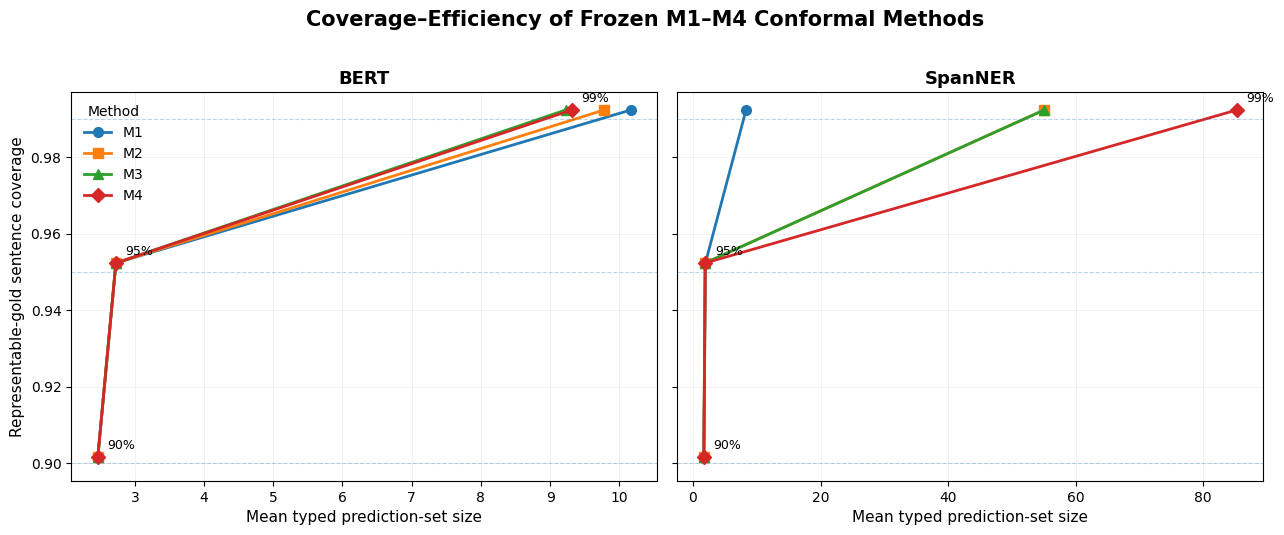

Saved figure: /kaggle/working/05_conformal_prediction_M1_M4/figures/coverage_efficiency_M1_M4.png


In [15]:
import matplotlib.pyplot as plt

FIGURE_OUTPUT_DIR = OUTPUT_ROOT / "figures"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

method_markers = {
    "M1": "o",
    "M2": "s",
    "M3": "^",
    "M4": "D",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
    sharey=True,
)

for ax, model in zip(
    axes,
    ["BERT", "SpanNER"],
):
    model_df = (
        calibration_operating_results_df.loc[
            calibration_operating_results_df["Model"].eq(model)
        ]
        .sort_values(
            ["Method", "Target Coverage"]
        )
    )

    for method in ["M1", "M2", "M3", "M4"]:
        method_df = (
            model_df.loc[
                model_df["Method"].eq(method)
            ]
            .sort_values("Target Coverage")
        )

        ax.plot(
            method_df[
                "Calibration Mean Typed Set Size"
            ],
            method_df[
                "Calibration Representable-Gold Coverage"
            ],
            marker=method_markers[method],
            markersize=7,
            linewidth=2,
            label=method,
        )

        # Label each operating point once using M4 so the figure
        # remains readable where several methods overlap.
        if method == "M4":
            for _, row in method_df.iterrows():
                ax.annotate(
                    f"{int(row['Target Coverage'] * 100)}%",
                    (
                        row[
                            "Calibration Mean Typed Set Size"
                        ],
                        row[
                            "Calibration Representable-Gold Coverage"
                        ],
                    ),
                    xytext=(7, 6),
                    textcoords="offset points",
                    fontsize=9,
                )

    # Nominal target levels provide reference for the empirical coverage.
    for target in TARGET_COVERAGES:
        ax.axhline(
            target,
            linestyle="--",
            linewidth=0.8,
            alpha=0.30,
        )

    ax.set_title(
        model,
        fontsize=13,
        fontweight="semibold",
    )

    ax.set_xlabel(
        "Mean typed prediction-set size",
        fontsize=11,
    )

    ax.grid(
        alpha=0.18,
        linewidth=0.7,
    )

axes[0].set_ylabel(
    "Representable-gold sentence coverage",
    fontsize=11,
)

axes[0].legend(
    title="Method",
    frameon=False,
)

fig.suptitle(
    "Coverage–Efficiency of Frozen M1–M4 Conformal Methods",
    fontsize=15,
    fontweight="semibold",
    y=1.02,
)

fig.tight_layout()

figure_path = (
    FIGURE_OUTPUT_DIR
    / "coverage_efficiency_M1_M4.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", figure_path)

### 7.2 Prediction-Set Expansion at Higher Coverage

The previous figure compares coverage and efficiency jointly. The following view focuses specifically on how prediction-set size changes as the requested conformal coverage increases from 90% to 99%.

This is important because similar behaviour at the primary 90% operating point does not imply that the methods remain equally efficient under more demanding coverage requirements. Rapid set expansion indicates that additional coverage is being obtained at a substantial efficiency cost.

The two architectures are displayed on separate axes because their high-coverage set sizes differ considerably. The values remain the fitted operating characteristics of the 650-sentence conformal-calibration population rather than held-out generalisation estimates.

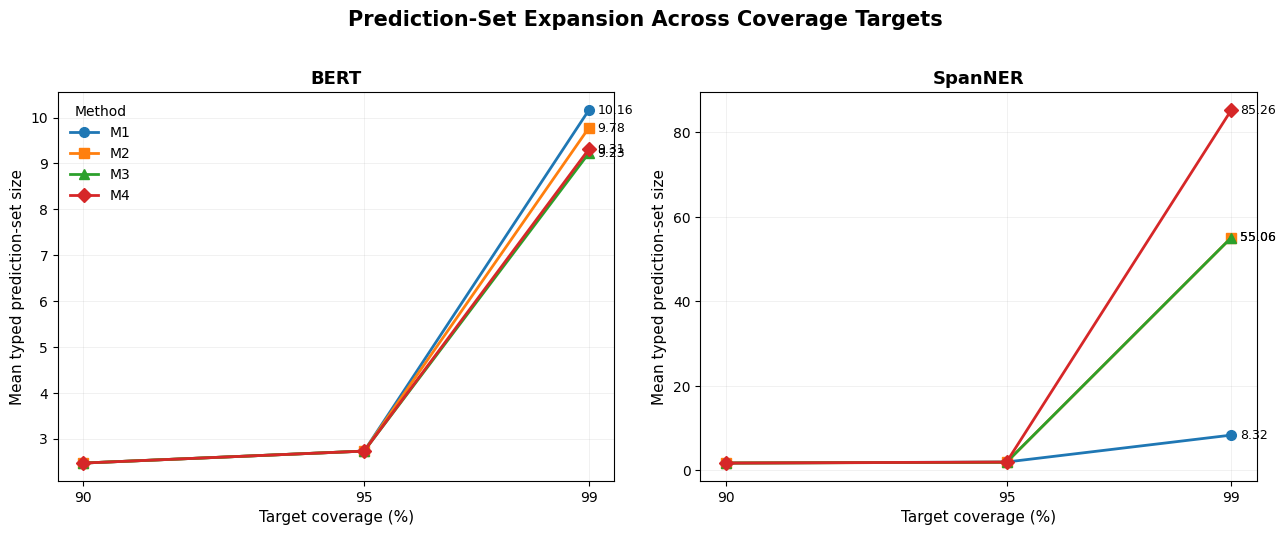

Saved figure: /kaggle/working/05_conformal_prediction_M1_M4/figures/prediction_set_expansion_M1_M4.png


In [16]:
# Visualise how the frozen prediction sets expand as higher coverage is requested.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
)

target_percentages = {
    0.90: 90,
    0.95: 95,
    0.99: 99,
}

for ax, model in zip(
    axes,
    ["BERT", "SpanNER"],
):
    model_df = (
        calibration_operating_results_df.loc[
            calibration_operating_results_df["Model"].eq(model)
        ]
        .copy()
    )

    for method in ["M1", "M2", "M3", "M4"]:
        method_df = (
            model_df.loc[
                model_df["Method"].eq(method)
            ]
            .sort_values("Target Coverage")
        )

        x_values = (
            method_df["Target Coverage"]
            .map(target_percentages)
            .to_numpy()
        )

        y_values = (
            method_df[
                "Calibration Mean Typed Set Size"
            ]
            .to_numpy(dtype=float)
        )

        ax.plot(
            x_values,
            y_values,
            marker=method_markers[method],
            markersize=7,
            linewidth=2,
            label=method,
        )

        # Label the 99% endpoint because this is where the largest
        # efficiency differences emerge.
        final_row = method_df.iloc[-1]

        ax.annotate(
            f"{final_row['Calibration Mean Typed Set Size']:.2f}",
            (
                99,
                final_row[
                    "Calibration Mean Typed Set Size"
                ],
            ),
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=9,
            va="center",
        )

    ax.set_title(
        model,
        fontsize=13,
        fontweight="semibold",
    )

    ax.set_xlabel(
        "Target coverage (%)",
        fontsize=11,
    )

    ax.set_ylabel(
        "Mean typed prediction-set size",
        fontsize=11,
    )

    ax.set_xticks(
        [90, 95, 99]
    )

    ax.grid(
        alpha=0.18,
        linewidth=0.7,
    )

axes[0].legend(
    title="Method",
    frameon=False,
)

fig.suptitle(
    "Prediction-Set Expansion Across Coverage Targets",
    fontsize=15,
    fontweight="semibold",
    y=1.02,
)

fig.tight_layout()

set_expansion_figure_path = (
    FIGURE_OUTPUT_DIR
    / "prediction_set_expansion_M1_M4.png"
)

fig.savefig(
    set_expansion_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved figure:",
    set_expansion_figure_path,
)

## 8. Final M1–M4 Freeze and Downstream Handoff

The core conformal experiment is now complete.

The candidate universes, temperature-scaled confidence constructions, architecture-specific deterministic boundary-uncertainty definitions, M1–M4 score formulations, validation-selected \(\lambda\) values, and independent conformal thresholds are frozen for all subsequent experiments.

The final \(\lambda\) configurations are:

| Model       | M2                 | M3                                    | M4                                    |
| ----------- | ------------------ | ------------------------------------- | ------------------------------------- |
| **BERT**    | \(\lambda = 0.01\) | \(\lambda_s = 0,\ \lambda_e = 0.01\)  | \(\lambda_s = 0,\ \lambda_e = 0.01\)  |
| **SpanNER** | \(\lambda = 1.0\)  | \(\lambda_s = 1.0,\ \lambda_e = 1.0\) | \(\lambda_s = 1.0,\ \lambda_e = 0.3\) |

At the primary 90% calibration operating point, the four BERT methods produced identical prediction-set efficiency. SpanNER M4 produced only a negligible reduction in mean set size relative to the fixed alternatives. At higher requested coverage, the relative behaviour changed substantially, with M4 providing no consistent efficiency advantage and exhibiting particularly large prediction-set expansion for SpanNER at 99%.

These results do not establish a uniform coverage–efficiency advantage for uncertainty-adaptive M4. The mechanism underlying this behaviour is examined separately in Notebook 06.

No further \(\lambda\) selection, score redefinition, or conformal calibration is permitted after this notebook. The frozen specification is propagated unchanged to the matched-width analysis, controlled-noise evaluation, locked CoNLL-2003 test, and WNUT-17 external replication.

The official CoNLL-2003 test set has not been accessed.


### 8.1 Submission Artefacts

The final notebook exports a compact reproducibility record containing:

- the complete validation λ-search results;
- the selected M1–M4 configurations;
- the final 90%, 95% and 99% conformal thresholds;
- validation and calibration coverage–efficiency summaries;
- sentence-level conformal-calibration scores;
- candidate-level score components required for the subsequent matched-width and M4 mechanism analysis;
- one frozen JSON specification for use by all downstream notebooks.

Candidate-component tables retain the quantities required to reconstruct or diagnose M1–M4 without repeating model inference. They contain no official test information.

In [17]:
RESULTS_OUTPUT_DIR = OUTPUT_ROOT / "results"
DOWNSTREAM_OUTPUT_DIR = OUTPUT_ROOT / "downstream"

RESULTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOWNSTREAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Save compact result tables used in the dissertation and downstream analysis.
selected_lambda_path = (
    RESULTS_OUTPUT_DIR
    / "selected_M1_M4_lambda_configurations.csv"
)

lambda_search_path = (
    RESULTS_OUTPUT_DIR
    / "validation_lambda_search_results.csv"
)

quantile_path = (
    RESULTS_OUTPUT_DIR
    / "final_conformal_quantiles.csv"
)

primary_results_path = (
    RESULTS_OUTPUT_DIR
    / "primary_90pct_coverage_efficiency.csv"
)

operating_results_path = (
    RESULTS_OUTPUT_DIR
    / "calibration_operating_results.csv"
)

validation_results_path = (
    RESULTS_OUTPUT_DIR
    / "frozen_validation_operating_results.csv"
)

sentence_scores_path = (
    RESULTS_OUTPUT_DIR
    / "conformal_calibration_sentence_scores.csv"
)

fold_assignment_path = (
    RESULTS_OUTPUT_DIR
    / "validation_lambda_fold_assignment.csv"
)


selected_lambda_df.to_csv(
    selected_lambda_path,
    index=False,
)

all_tuning_results_df.to_csv(
    lambda_search_path,
    index=False,
)

conformal_quantiles_df.to_csv(
    quantile_path,
    index=False,
)

primary_90_results_df.to_csv(
    primary_results_path,
    index=False,
)

calibration_operating_results_df.to_csv(
    operating_results_path,
    index=False,
)

frozen_validation_results_df.to_csv(
    validation_results_path,
    index=False,
)

conformal_sentence_scores_df.to_csv(
    sentence_scores_path,
    index=False,
)

validation_fold_df.to_csv(
    fold_assignment_path,
    index=False,
)


# Retain only the candidate-level quantities required for downstream
# matched-width and M4 mechanism analyses.
candidate_component_columns = [
    "sentence_id",
    "start",
    "end",
    "entity_type",
    "word_length",
    "base_confidence",
    "base_nonconformity",
    "start_uncertainty",
    "end_uncertainty",
    "start_rank_penalty",
    "end_rank_penalty",
    "is_gold_candidate",
]

bert_validation_components_path = (
    DOWNSTREAM_OUTPUT_DIR
    / "bert_validation_conformal_components.parquet"
)

spanner_validation_components_path = (
    DOWNSTREAM_OUTPUT_DIR
    / "spanner_validation_conformal_components.parquet"
)

bert_calibration_components_path = (
    DOWNSTREAM_OUTPUT_DIR
    / "bert_conformal_calibration_components.parquet"
)

spanner_calibration_components_path = (
    DOWNSTREAM_OUTPUT_DIR
    / "spanner_conformal_calibration_components.parquet"
)


bert_validation_candidates_df[
    candidate_component_columns
].to_parquet(
    bert_validation_components_path,
    index=False,
)

spanner_validation_typed_df[
    candidate_component_columns
].to_parquet(
    spanner_validation_components_path,
    index=False,
)

bert_conformal_candidates_df[
    candidate_component_columns
    + ["score_M1", "score_M2", "score_M3", "score_M4"]
].to_parquet(
    bert_calibration_components_path,
    index=False,
)

spanner_conformal_typed_df[
    candidate_component_columns
    + ["score_M1", "score_M2", "score_M3", "score_M4"]
].to_parquet(
    spanner_calibration_components_path,
    index=False,
)


# Convert the selected configurations into a clean nested specification.
frozen_lambda_specification = {}

for model in ["BERT", "SpanNER"]:
    frozen_lambda_specification[model] = {}

    for method in ["M1", "M2", "M3", "M4"]:
        row = selected_lambda_df.loc[
            selected_lambda_df["Model"].eq(model)
            & selected_lambda_df["Method"].eq(method)
        ]

        if len(row) != 1:
            raise RuntimeError(
                f"Expected one selected configuration for {model} {method}."
            )

        row = row.iloc[0]

        frozen_lambda_specification[model][method] = {
            "lambda_shared": float(
                row["Lambda Shared"]
            ),
            "lambda_start": float(
                row["Lambda Start"]
            ),
            "lambda_end": float(
                row["Lambda End"]
            ),
            "selection_status": str(
                row["Selection Status"]
            ),
        }


# Store every architecture-method-target conformal threshold explicitly.
frozen_quantile_specification = {}

for row in conformal_quantiles_df.itertuples(index=False):
    model = str(row.Model)
    method = str(row.Method)
    target = f"{int(round(row._2 * 100))}%"

    frozen_quantile_specification.setdefault(
        model,
        {},
    ).setdefault(
        method,
        {},
    )[target] = {
        "target_coverage": float(row._2),
        "order_rank": int(row._3),
        "q_hat": float(row.q_hat),
        "calibration_representable_gold_coverage": float(
            row._5
        ),
    }


final_conformal_specification = {
    "status": "M1_M4_CONFORMAL_SPECIFICATION_FROZEN",

    "seed": SEED,

    "populations": {
        "probability_calibration_sentences": (
            PROBABILITY_CALIBRATION_SENTENCES
        ),
        "lambda_development_sentences": (
            VALIDATION_SENTENCES
        ),
        "conformal_calibration_sentences": (
            CONFORMAL_CALIBRATION_SENTENCES
        ),
    },

    "temperatures": {
        "BERT": BERT_TEMPERATURE,
        "SpanNER": SPANNER_TEMPERATURE,
    },

    "candidate_universes": {
        "BERT": (
            "all contiguous original-word spans "
            "x PER/ORG/LOC/MISC"
        ),
        "SpanNER": (
            "all original-word spans of width <=4 "
            "x PER/ORG/LOC/MISC"
        ),
    },

    "scores": {
        "M1": "1-c",
        "M2": "(1-c) + 0.5*lambda*(R_s+R_e)",
        "M3": (
            "(1-c) + 0.5*"
            "(lambda_s*R_s + lambda_e*R_e)"
        ),
        "M4": (
            "(1-c) + 0.5*"
            "[lambda_s*(1-u_s)*R_s + "
            "lambda_e*(1-u_e)*R_e]"
        ),
    },

    "boundary_uncertainty": {
        "BERT": {
            "start": (
                "P(I-X at start) / "
                "[P(B-X at start)+P(I-X at start)+epsilon]"
            ),
            "end": (
                "P(I-X immediately after end), "
                "or 0 at sentence end"
            ),
        },
        "SpanNER": {
            "start": (
                "strongest same-type alternative-start probability "
                "/ (candidate probability + competitor probability + epsilon)"
            ),
            "end": (
                "strongest same-type alternative-end probability "
                "/ (candidate probability + competitor probability + epsilon)"
            ),
            "no_competitor_conformal_convention": 0.0,
        },
    },

    "coverage_definition": (
        "sentence-level coverage of all representable gold typed spans"
    ),

    "full_gold_coverage_definition": (
        "sentence-level coverage requiring all original gold spans "
        "to be structurally representable and included"
    ),

    "set_size_definition": (
        "number of typed span candidates satisfying score <= q_hat "
        "per sentence"
    ),

    "lambda_selection": {
        "procedure": (
            "five-fold duplicate-safe validation pseudo-conformal cross-fitting"
        ),
        "primary_coverage_target": PRIMARY_TUNING_COVERAGE,
        "fallback_coverage_floor": (
            PRIMARY_TUNING_COVERAGE
            - COVERAGE_FALLBACK_TOLERANCE
        ),
        "selection_priority": [
            "coverage eligibility",
            "minimum mean typed prediction-set size",
            "minimum total regularisation",
            "higher coverage",
        ],
        "selected": frozen_lambda_specification,
    },

    "finite_sample_quantile": (
        "k = ceil((n + 1) * target_coverage), "
        "q_hat = k-th smallest sentence calibration score"
    ),

    "conformal_quantiles": frozen_quantile_specification,

    "binary_correctness_calibration_role": (
        "secondary_diagnostic"
    ),
    "binary_calibrators_used_in_primary_M1_M4": False,
    "mc_dropout_used_in_primary_M1_M4": False,
    "M5_in_primary_experiment": False,

    "method_development_complete": True,
    "lambda_retuning_permitted_downstream": False,
    "official_test_accessed": False,

    "next_notebook": (
        "06_Matched_Width_and_M4_Mechanism_Analysis"
    ),
}


final_specification_path = (
    CONFIG_OUTPUT_DIR
    / "final_conformal_specification.json"
)

with final_specification_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_conformal_specification,
        file,
        indent=2,
    )


# Final completion record for the notebook.
completion_record = {
    "notebook": "05_Conformal_Prediction_and_M1_M4",
    "status": "COMPLETE",
    "models": ["BERT", "SpanNER"],
    "methods": ["M1", "M2", "M3", "M4"],
    "target_coverages": list(TARGET_COVERAGES),
    "validation_sentences": VALIDATION_SENTENCES,
    "conformal_calibration_sentences": (
        CONFORMAL_CALIBRATION_SENTENCES
    ),
    "method_development_complete": True,
    "conformal_quantiles_frozen": True,
    "official_test_accessed": False,
    "next_notebook": (
        "06_Matched_Width_and_M4_Mechanism_Analysis"
    ),
}

completion_record_path = (
    OUTPUT_ROOT / "completion_record.json"
)

with completion_record_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=2,
    )


export_summary_df = pd.DataFrame(
    [
        {
            "Artefact": "Frozen conformal specification",
            "File": final_specification_path.name,
        },
        {
            "Artefact": "Selected lambda configurations",
            "File": selected_lambda_path.name,
        },
        {
            "Artefact": "Final conformal quantiles",
            "File": quantile_path.name,
        },
        {
            "Artefact": "Primary 90% results",
            "File": primary_results_path.name,
        },
        {
            "Artefact": "Validation lambda search",
            "File": lambda_search_path.name,
        },
        {
            "Artefact": "BERT validation components",
            "File": bert_validation_components_path.name,
        },
        {
            "Artefact": "SpanNER validation components",
            "File": spanner_validation_components_path.name,
        },
        {
            "Artefact": "Completion record",
            "File": completion_record_path.name,
        },
    ]
)

print("Table: Final Notebook 05 Handoff")
display(export_summary_df)

print(
    "\nFinal conformal specification frozen:",
    final_specification_path.is_file(),
)
print(
    "Method development complete:",
    True,
)
print(
    "Lambda retuning permitted downstream:",
    False,
)
print(
    "Binary correctness calibrators used in M1-M4:",
    False,
)
print(
    "Official CoNLL test accessed:",
    False,
)

Table: Final Notebook 05 Handoff


,Artefact,File
0,Frozen conformal specification,final_conformal_specification.json
1,Selected lambda configurations,selected_M1_M4_lambda_configurations.csv
2,Final conformal quantiles,final_conformal_quantiles.csv
3,Primary 90% results,primary_90pct_coverage_efficiency.csv
4,Validation lambda search,validation_lambda_search_results.csv
5,BERT validation components,bert_validation_conformal_components.parquet
6,SpanNER validation components,spanner_validation_conformal_components.parquet
7,Completion record,completion_record.json



Final conformal specification frozen: True
Method development complete: True
Lambda retuning permitted downstream: False
Binary correctness calibrators used in M1-M4: False
Official CoNLL test accessed: False


## 9. Notebook Summary

This notebook established the final conformal prediction specification for BERT and SpanNER using the frozen validation and conformal-calibration populations.

The predefined M1–M4 scoring formulations were evaluated using architecture-native candidate supports and deterministic boundary-uncertainty signals. Model-specific λ values were selected exclusively through grouped five-fold validation cross-fitting and were subsequently frozen before the independent 650-sentence conformal-calibration population was opened. Final conformal thresholds were then estimated at 90%, 95% and 99% target coverage using the finite-sample order-statistic convention.

The rebuilt experiment reproduced the previously validated λ selections for both architectures. At the primary 90% calibration operating point, uncertainty-adaptive M4 provided no substantive efficiency advantage over the fixed alternatives. At higher target coverage, the relative behaviour became increasingly architecture-dependent, with particularly large SpanNER M4 prediction sets at 99% coverage.

The results therefore motivate a focused analysis of candidate-width effects and the mechanism of M4's adaptive relaxation. These questions are addressed in Notebook 06.
